# **Aulas Práticas do Módulo de Aprendizagem de Máquinas em Séries Temporais da Pós graduação em Inteligência Artificial**

*Profa Maria Eva Clemencia Fonseca Castro Silva*

UNIDADE 4 - Aplicações Práticas

**Modelagem e Previsão da Taxa de Desemprego (UNRATE)**

## **Contextualização**

Nesta aula prática será desenvolvido um fluxo completo de análise de séries temporais aplicado a uma base real. O objetivo é integrar teoria e prática, reproduzindo no ambiente computacional todos os conceitos trabalhados em sala:

- Análise descritiva de séries temporais  
- Identificação de estacionariedade  
- Modelagem estatística (ARIMA e SARIMA)  
- Modelagem com Aprendizado de Máquina  
- Avaliação comparativa de desempenho preditivo  

O foco não é apenas ajustar modelos, mas compreender o processo metodológico completo:
  
**Identificação → Estimação → Diagnóstico → Previsão → Avaliação**

---

## **Base de Dados Utilizada**

Será utilizada a série **UNRATE (U.S. Unemployment Rate)**, que representa a taxa de desemprego dos Estados Unidos.

### **Características da base:**
- Fonte oficial: **FRED (Federal Reserve Economic Data)**  
- Instituição mantenedora: Federal Reserve Bank of St. Louis  
- Frequência: **Mensal**  
- Variável: Taxa de desemprego (% da força de trabalho)  
- Período analisado: A partir de 1990  

A série é carregada diretamente no Python por meio da biblioteca `pandas_datareader`, garantindo reprodutibilidade e transparência dos dados.

---

## **Estrutura da Aula**

A aula está organizada em seis blocos:

1. **Carregamento e organização da série**
2. **Análise descritiva completa**
   - Visualização temporal
   - Estatísticas descritivas
   - Histograma e boxplot
   - ACF e PACF
   - Testes ADF e KPSS
3. **Modelagem ARIMA**
4. **Modelagem SARIMA**
5. **Modelos de Aprendizado de Máquina**
   - Árvore de Decisão
   - Random Forest
   - XGBoost
   - MLP
   - LSTM
6. **Comparação consolidada dos modelos**

---

## **Objetivo Final**

Ao final da aula, o aluno deverá ser capaz de:

- Diagnosticar estacionariedade de uma série temporal.
- Interpretar ACF, PACF, ADF e KPSS.
- Ajustar modelos ARIMA e SARIMA.
- Transformar séries temporais em formato supervisionado.
- Aplicar modelos de Machine Learning e Deep Learning em previsão.
- Comparar modelos com base em métricas quantitativas (MAE, RMSE, MAPE e R²).

A proposta é demonstrar que modelos estatísticos clássicos e modelos de aprendizado de máquina podem ser analisados dentro de uma mesma estrutura metodológica.

### **0) IMPORTS (BIBLIOTECAS)**


In [ ]:
# -----------------------------------------------------------
# 0) IMPORTS (BIBLIOTECAS)
# -----------------------------------------------------------

import warnings  # Importa o módulo para controle de avisos.
warnings.filterwarnings("ignore")  # Oculta warnings para não poluir a saída do notebook.

import numpy as np  # Importa NumPy para operações numéricas.
import pandas as pd  # Importa Pandas para manipulação de dados e séries temporais.
import matplotlib.pyplot as plt  # Importa Matplotlib para gráficos.

import statsmodels.api as sm  # Importa Statsmodels para ARIMA/SARIMA e diagnósticos.
from statsmodels.tsa.stattools import adfuller, kpss  # Importa testes ADF e KPSS (estacionariedade).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Importa funções de ACF e PACF.
from statsmodels.graphics.gofplots import qqplot  # Importa QQ-plot (normalidade).

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Importa métricas.
from sklearn.tree import DecisionTreeRegressor  # Importa Árvore de Decisão para regressão.
from sklearn.ensemble import RandomForestRegressor  # Importa Random Forest para regressão.
from sklearn.pipeline import Pipeline  # Importa Pipeline para encadear pré-processamento + modelo.
from sklearn.preprocessing import StandardScaler  # Importa padronização (essencial para MLP).
from sklearn.neural_network import MLPRegressor  # Importa MLP para regressão.

import tensorflow as tf  # Importa TensorFlow para redes neurais profundas.
from tensorflow.keras import layers, models  # Importa camadas e modelos do Keras.

from scipy import stats  # Importa SciPy para QQ-plot robusto via probplot (evita erro de broadcast do statsmodels.qqplot).

from pandas_datareader import data as pdr  # Importa conector para baixar séries do FRED.

### **0.1) FUNÇÕES UTILITÁRIAS**

In [ ]:
# -----------------------------------------------------------
# 0.1) FUNÇÕES UTILITÁRIAS
#
# Objetivo do bloco:
# - Padronizar cálculos de métricas (RMSE, MAPE, MAE, R²)
# - Padronizar split temporal (treino/teste) sem embaralhar
# - Blindar avaliação contra NaN e desalinhamento de índices
# - Padronizar gráficos ACF/PACF e testes ADF/KPSS
# - Criar features de defasagem (ML supervisionado)
# - Diagnóstico de resíduos para ML/DL (sem mensagens e sem “figuras vazias”)
# - Converter série em sequências para LSTM
# -----------------------------------------------------------

def rmse(y_true, y_pred):  # Função: RMSE (raiz do erro quadrático médio).
    return np.sqrt(mean_squared_error(y_true, y_pred))  # Calcula MSE e aplica raiz para voltar à escala original.

def mape(y_true, y_pred):  # Função: MAPE (erro percentual absoluto médio) com proteção contra zeros.
    y_true = np.array(y_true)  # Converte y_true para array NumPy (padroniza operações vetoriais).
    y_pred = np.array(y_pred)  # Converte y_pred para array NumPy.
    mask = y_true != 0  # Cria máscara: mantém apenas posições onde o denominador não é zero.
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100  # Calcula MAPE em % apenas em posições válidas.

def train_test_split_time(series, test_size):  # Função: split temporal preservando ordem (sem shuffle).
    split_point = len(series) - test_size  # Define ponto de corte: últimos "test_size" pontos serão teste.
    train = series.iloc[:split_point]  # Seleciona parte inicial como treino.
    test = series.iloc[split_point:]  # Seleciona parte final como teste.
    return train, test  # Retorna treino e teste.

def align_and_dropna(y_true, y_pred):  # Função: alinhar y_true e y_pred por índice e remover NaN.
    y_true_al, y_pred_al = y_true.align(y_pred, join="inner")  # Alinha pelas datas comuns (interseção do índice).
    mask = (~y_true_al.isna()) & (~y_pred_al.isna())  # Mantém somente pares onde ambos existem e não são NaN.
    return y_true_al[mask], y_pred_al[mask]  # Retorna séries alinhadas e filtradas.

def evaluate_forecast(y_true, y_pred, model_name="Modelo"):  # Função: calcular métricas padronizadas e retornar em dicionário.
    y_true_al, y_pred_al = align_and_dropna(y_true, y_pred)  # Garante comparação justa (mesmas datas e sem NaN).
    metrics = {  # Consolida métricas em formato “pronto para tabela”.
        "Modelo": model_name,  # Identificador do modelo (para ranking posterior).
        "MAE": mean_absolute_error(y_true_al, y_pred_al),  # MAE: erro absoluto médio.
        "RMSE": rmse(y_true_al, y_pred_al),  # RMSE: penaliza mais erros grandes.
        "MAPE(%)": mape(y_true_al, y_pred_al),  # MAPE: interpretação percentual (com cuidado em valores próximos de 0).
        "R2": r2_score(y_true_al, y_pred_al)  # R²: proporção de variância explicada (pode ser negativo fora da amostra).
    }
    return metrics  # Retorna dicionário.

def plot_acf_pacf(series, lags=40, title_prefix="Série"):  # Função: plotar ACF e PACF em uma figura padronizada.
    s = series.dropna()  # Remove NaN para evitar erro em funções de autocorrelação.
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))  # Cria figura com 2 painéis (ACF e PACF).
    plot_acf(s, ax=ax[0], lags=lags)  # Plota ACF (associação da série com ela mesma em defasagens).
    ax[0].set_title(f"{title_prefix} — ACF")  # Título do painel ACF.
    ax[0].set_xlabel("Defasagem (lag)")  # Eixo x ACF.
    ax[0].set_ylabel("Autocorrelação")  # Eixo y ACF.
    plot_pacf(s, ax=ax[1], lags=lags, method="ywm")  # Plota PACF (associação “direta” removendo lags intermediários).
    ax[1].set_title(f"{title_prefix} — PACF")  # Título do painel PACF.
    ax[1].set_xlabel("Defasagem (lag)")  # Eixo x PACF.
    ax[1].set_ylabel("Autocorrelação parcial")  # Eixo y PACF.
    plt.tight_layout()  # Ajusta layout para não cortar textos.
    plt.show()  # Exibe figura.

def stationarity_tests(series, name="Série"):  # Função: executar ADF e KPSS e imprimir resultados (diagnóstico de estacionariedade).
    s = series.dropna()  # Remove NaN para evitar erro.
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s)  # ADF: H0 = não estacionária (raiz unitária).
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression="c", nlags="auto")  # KPSS: H0 = estacionária (em nível).
    print(f"{name} — ADF estatística: {adf_stat:.4f}")  # Mostra estatística do ADF.
    print(f"{name} — ADF p-valor:      {adf_p:.4f}")  # Mostra p-valor do ADF.
    print(f"{name} — ADF críticos:     {adf_crit}")  # Mostra valores críticos para 1%, 5% e 10%.
    print(f"{name} — KPSS estatística: {kpss_stat:.4f}")  # Mostra estatística do KPSS.
    print(f"{name} — KPSS p-valor:     {kpss_p:.4f}")  # Mostra p-valor do KPSS.
    print(f"{name} — KPSS lags:        {kpss_lags}")  # Mostra nº de lags usados no KPSS.
    print(f"{name} — KPSS críticos:    {kpss_crit}")  # Mostra valores críticos para 10%, 5%, 2.5% e 1%.

def make_lagged_features(series, lags=12):  # Função: transformar série em problema supervisionado via defasagens.
    df_l = pd.DataFrame({"y": series})  # Cria DataFrame com a variável alvo y(t).
    for k in range(1, lags + 1):  # Para cada defasagem desejada.
        df_l[f"lag_{k}"] = df_l["y"].shift(k)  # Cria feature lag_k = y(t-k) deslocando a série.
    df_l = df_l.dropna()  # Remove linhas iniciais que ficaram incompletas por causa dos shifts.
    X = df_l.drop(columns=["y"])  # Define X como matriz de features (lags).
    y_out = df_l["y"]  # Define y como alvo (valor atual).
    return X, y_out  # Retorna X e y.

def ml_residual_diagnostics(y_true, y_pred, title_prefix="Modelo"):  # Função: diagnóstico de resíduos para ML/DL (sem prints e sem “figuras vazias”).
    y_true_al, y_pred_al = align_and_dropna(y_true, y_pred)  # Alinha observado e previsto (mesmas datas e sem NaN).
    if len(y_true_al) == 0:  # Se não houver dados alinhados, encerra silenciosamente.
        return  # Não faz nada.

    resid_vals = (y_true_al.values - y_pred_al.values).astype("float64").ravel()  # Calcula resíduos como vetor NumPy 1D (evita mismatch).
    resid_vals = resid_vals[~np.isnan(resid_vals)]  # Remove NaN residual (segurança adicional).
    if resid_vals.size == 0:  # Se não houver resíduos válidos, encerra silenciosamente.
        return  # Não faz nada.

    x = np.arange(resid_vals.size)  # Cria eixo x numérico (evita conflitos com índices de data em algumas rotinas).

    plt.figure(figsize=(12, 4))  # Abre figura para resíduos no tempo.
    plt.plot(x, resid_vals)  # Plota sequência de resíduos.
    plt.title(f"{title_prefix} — Resíduos (sequência temporal)")  # Título.
    plt.xlabel("Índice temporal (ordem)")  # Eixo x.
    plt.ylabel("Resíduo (y - ŷ)")  # Eixo y.
    plt.tight_layout()  # Ajusta layout.
    plt.show()  # Exibe.

    plt.figure(figsize=(6, 4))  # Abre figura para histograma.
    plt.hist(resid_vals, bins=20)  # Histograma dos resíduos.
    plt.title(f"{title_prefix} — Histograma dos resíduos")  # Título.
    plt.xlabel("Resíduo")  # Eixo x.
    plt.ylabel("Frequência")  # Eixo y.
    plt.tight_layout()  # Ajusta layout.
    plt.show()  # Exibe.

    try:  # Tenta QQ-plot via SciPy (mais estável que qqplot do statsmodels em alguns ambientes).
        from scipy import stats  # Importa SciPy localmente.
        plt.figure(figsize=(6, 4))  # Abre figura.
        stats.probplot(resid_vals, dist="norm", plot=plt)  # QQ-plot contra normal.
        plt.title(f"{title_prefix} — QQ-plot dos resíduos")  # Título.
        plt.tight_layout()  # Ajusta layout.
        plt.show()  # Exibe.
    except Exception:  # Se SciPy não estiver disponível, não exibe nada adicional.
        plt.close("all")  # Fecha qualquer figura parcialmente criada (evita “quadrados vazios”).
        return  # Sai silenciosamente.

    # Observação: conforme sua regra, ML/DL não precisa de ACF/PACF.
    # Portanto, esta função NÃO chama ACF/PACF em nenhum cenário.

def make_sequences(series, window=12):  # Função: converter série 1D em janelas (sequências) para LSTM.
    values = series.values.astype("float32")  # Converte valores para float32 (padrão do TensorFlow).
    X, y_seq = [], []  # Inicializa listas para armazenar janelas (X) e alvos (y).
    for i in range(window, len(values)):  # Varre a série a partir da primeira janela completa.
        X.append(values[i-window:i])  # X recebe a janela de tamanho "window" imediatamente anterior.
        y_seq.append(values[i])  # y recebe o valor seguinte (prever 1 passo à frente).
    X = np.array(X)  # Converte lista X para array NumPy.
    y_seq = np.array(y_seq)  # Converte lista y para array NumPy.
    X = X.reshape((X.shape[0], X.shape[1], 1))  # Ajusta forma para LSTM: (amostras, passos, features=1).
    return X, y_seq  # Retorna arrays prontos para treino/teste.

### **1) CARREGAMENTO DA BASE (Taxa de desemprego)**

In [ ]:
# -----------------------------------------------------------
# 1) CARREGAMENTO DA BASE (Taxa de desemprego)
# Fonte: FRED (UNRATE) — frequência mensal
# -----------------------------------------------------------

df_un = pdr.DataReader("UNRATE", "fred", start="1990-01-01")  # Baixa a série UNRATE a partir de 1990.
df_un = df_un.rename(columns={"UNRATE": "unrate"}).reset_index()  # Renomeia coluna e transforma índice em coluna.

df_un["DATE"] = pd.to_datetime(df_un["DATE"])  # Converte coluna de data para datetime.
df_un = df_un.sort_values("DATE")  # Ordena cronologicamente.
df_un = df_un.set_index("DATE")  # Define DATE como índice temporal.

y = df_un["unrate"].asfreq("MS")  # Impõe grade mensal (Month Start).
y = y.dropna()  # Remove NA para evitar problemas em métricas e modelos.

print("Série carregada (head):")  # Identificador.
print(y.head())  # Mostra primeiras observações.
print("Período:", y.index.min(), "até", y.index.max())  # Mostra período.
print("N pontos:", len(y))  # Mostra tamanho.

Série carregada (head):
DATE
1990-01-01    5.4
1990-02-01    5.3
1990-03-01    5.2
1990-04-01    5.4
1990-05-01    5.4
Name: unrate, dtype: float64
Período: 1990-01-01 00:00:00 até 2026-01-01 00:00:00
N pontos: 432


### **2) ANÁLISE DESCRITIVA COMPLETA**

**2.1) VISÃO GERAL DA SÉRIE (GRÁFICO NO TEMPO)**

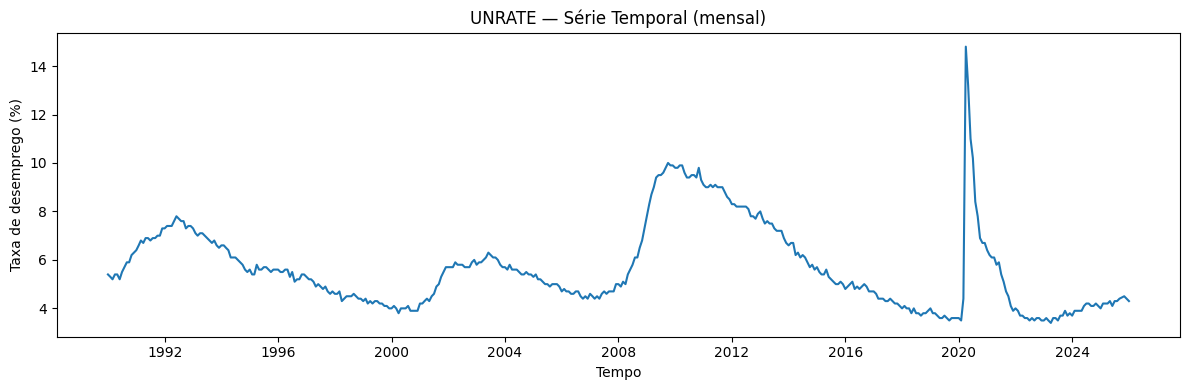

In [ ]:
# -----------------------------------------------------------
# 2) ANÁLISE DESCRITIVA COMPLETA
# Itens exigidos: Série no tempo, Descritiva (describe), Histograma, Boxplot,
# ACF, PACF, Testes de estacionariedade (ADF e KPSS)
#
# Observação didática:
# - Esta etapa é “governança analítica”: entender distribuição, dispersão, forma
#   e dependência temporal antes de ajustar modelos.
# -----------------------------------------------------------

# -------------------------
# 2.1) VISÃO GERAL DA SÉRIE (GRÁFICO NO TEMPO)
# -------------------------

plt.figure(figsize=(12, 4))  # Cria a área (figura) onde o gráfico será desenhado.
plt.plot(y.index, y.values)  # Plota a série usando o índice temporal (datas) no eixo x e os valores no eixo y.
plt.title("UNRATE — Série Temporal (mensal)")  # Define o título principal do gráfico.
plt.xlabel("Tempo")  # Nomeia o eixo x.
plt.ylabel("Taxa de desemprego (%)")  # Nomeia o eixo y.
plt.tight_layout()  # Ajusta automaticamente espaçamentos (evita cortes de texto).
plt.show()  # Exibe o gráfico.

A série apresenta comportamento cíclico ao longo do tempo, com períodos claros de alta e queda do desemprego, refletindo os ciclos econômicos.

Observa-se um pico acentuado em 2020, caracterizando um choque exógeno relevante (pandemia), que altera temporariamente a dinâmica da série.

Visualmente, há indícios de não estacionariedade em nível, pois:

* A média varia ao longo do tempo.

* Existe persistência temporal.

* Há mudança estrutural evidente.

**Conclusão:** a série provavelmente requer diferenciação antes da modelagem ARIMA, o que será confirmado pelos testes formais (ADF e KPSS).

**2.2) DISPERSÃO E OUTLIERS (BOXPLOT)**

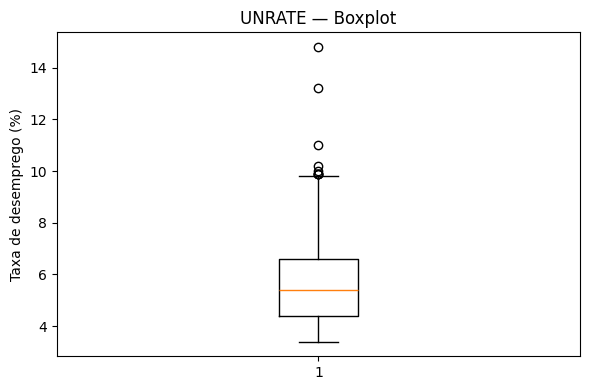

In [ ]:
# -------------------------
# 2.2) DISPERSÃO E OUTLIERS (BOXPLOT)
# -------------------------

plt.figure(figsize=(6, 4))  # Cria figura para o boxplot.
plt.boxplot(y.values)  # Desenha boxplot: mediana, quartis e possíveis outliers.
plt.title("UNRATE — Boxplot")  # Define título.
plt.ylabel("Taxa de desemprego (%)")  # Nomeia eixo y (eixo x não é informativo em boxplot 1D).
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe boxplot.

A mediana está próxima de 5,4%, coerente com a concentração principal da série.

O intervalo interquartil está aproximadamente entre 4,4% e 6,6%, indicando dispersão moderada.

Observam-se outliers superiores, associados aos períodos de crise, especialmente 2020.

Conclusão: a série apresenta assimetria positiva e valores extremos relevantes.

**2.3) DEPENDÊNCIA TEMPORAL (ACF e PACF)**

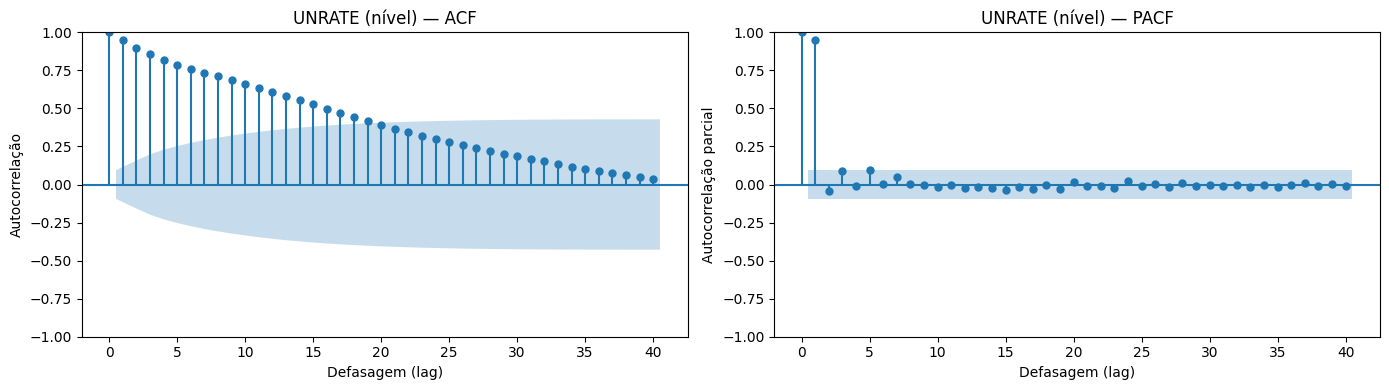

In [ ]:
# -------------------------
# 2.3) DEPENDÊNCIA TEMPORAL (ACF e PACF) — NÍVEL
# -------------------------

plot_acf_pacf(y, lags=40, title_prefix="UNRATE (nível)")  # Plota ACF e PACF para o nível (até 40 defasagens).

A ACF apresenta decaimento lento e persistente ao longo das defasagens, indicando forte dependência temporal e alta persistência da série.

A PACF mostra picos significativos nos primeiros lags, especialmente no lag 1 (e ainda relevante no lag 2), refletindo forte relação com períodos imediatamente anteriores.

A faixa azul representa o intervalo de confiança aproximado de 95%. Barras que ultrapassam esse limite indicam autocorrelação estatisticamente significativa.

Conclusão: o padrão observado é típico de série não estacionária em nível, sugerindo necessidade de diferenciação antes da modelagem ARIMA.

**2.4) ESTACIONARIEDADE (ADF e KPSS)**

In [ ]:
# -------------------------
# 2.4) ESTACIONARIEDADE (ADF e KPSS) — NÍVEL
# -------------------------

print("Testes de estacionariedade (nível):")  # Cabeçalho.
stationarity_tests(y, name="UNRATE (nível)")  # Executa ADF (H0: não estacionária) e KPSS (H0: estacionária).

Testes de estacionariedade (nível):
UNRATE (nível) — ADF estatística: -2.7019
UNRATE (nível) — ADF p-valor:      0.0737
UNRATE (nível) — ADF críticos:     {'1%': np.float64(-3.445757604526768), '5%': np.float64(-2.8683325885102855), '10%': np.float64(-2.5703882165206853)}
UNRATE (nível) — KPSS estatística: 0.3052
UNRATE (nível) — KPSS p-valor:     0.1000
UNRATE (nível) — KPSS lags:        12
UNRATE (nível) — KPSS críticos:    {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipython-input-1555/493429090.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression="c", nlags="auto")  # KPSS: H0 = estacionária (em nível).


No teste ADF, o p-valor (0,0737) é superior a 5%, portanto não se rejeita a hipótese nula de raiz unitária. Isso indica indício de não estacionariedade.

No teste KPSS, o p-valor (0,10) não permite rejeitar a hipótese nula de estacionariedade ao nível de 5%.

Os testes apresentam resultado limítrofe e parcialmente divergente, mas considerando:

* A análise visual,

* O comportamento da ACF,

* A presença de persistência,

**Conclui-se** que a série em nível provavelmente não é estacionária e requer diferenciação para modelagem ARIMA.

**2.5) TRANSFORMAÇÃO PARA APOIAR ESTACIONARIEDADE (1ª DIFERENÇA)**

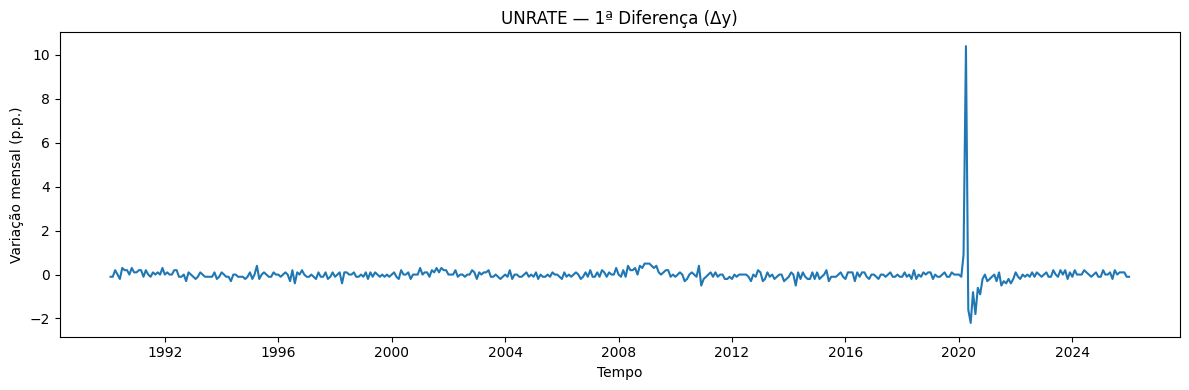

In [ ]:
# -------------------------
# 2.5) TRANSFORMAÇÃO PARA APOIAR ESTACIONARIEDADE (1ª DIFERENÇA)
# -------------------------

y_diff1 = y.diff(1).dropna()  # Calcula Δy_t = y_t - y_{t-1} e remove o primeiro NaN gerado pela diferença.

plt.figure(figsize=(12, 4))  # Cria figura para a série diferenciada.
plt.plot(y_diff1.index, y_diff1.values)  # Plota a 1ª diferença ao longo do tempo.
plt.title("UNRATE — 1ª Diferença (Δy)")  # Título do gráfico da diferença.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Variação mensal (p.p.)")  # Eixo y (pontos percentuais).
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe.

Após a diferenciação, a série passa a oscilar em torno de zero, indicando remoção da tendência.

A variância torna-se mais estável ao longo do tempo, exceto pelo choque extremo em 2020.

Visualmente, há indícios de estacionariedade após a diferenciação.

**Conclusão:** a primeira diferença parece adequada para modelagem ARIMA (d = 1).

**2.6) DEPENDÊNCIA TEMPORAL (ACF e PACF) — 1ª DIFERENÇA**

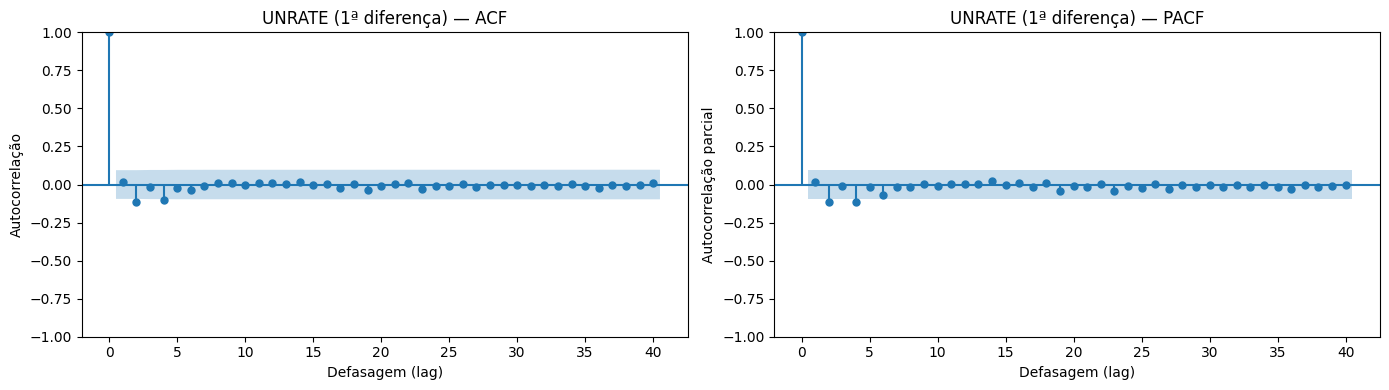

In [ ]:
# -------------------------
# 2.6) DEPENDÊNCIA TEMPORAL (ACF e PACF) — 1ª DIFERENÇA
# -------------------------

plot_acf_pacf(y_diff1, lags=40, title_prefix="UNRATE (1ª diferença)")  # Plota ACF/PACF na série diferenciada.

Após a diferenciação, a ACF apresenta corte rápido, sem decaimento persistente.

Observa-se um valor elevado no lag 0 (igual a 1), o que é esperado por definição e não deve ser interpretado.

Alguns primeiros lags podem ultrapassar levemente a faixa de confiança, o que é normal. O importante é que não haja padrão persistente de autocorrelação ao longo de muitos lags.

A PACF também não mostra estrutura relevante além dos primeiros lags.

**Conclusão:** a série diferenciada apresenta comportamento compatível com estacionariedade, indicando que d = 1 é adequado para modelagem ARIMA.

**2.7) ESTACIONARIEDADE (ADF e KPSS) — 1ª DIFERENÇA**

In [ ]:
# -------------------------
# 2.7) ESTACIONARIEDADE (ADF e KPSS) — 1ª DIFERENÇA
# -------------------------

print("Testes de estacionariedade (1ª diferença):")  # Cabeçalho.
stationarity_tests(y_diff1, name="UNRATE (1ª diferença)")  # Executa ADF e KPSS na série diferenciada.

Testes de estacionariedade (1ª diferença):
UNRATE (1ª diferença) — ADF estatística: -12.2292
UNRATE (1ª diferença) — ADF p-valor:      0.0000
UNRATE (1ª diferença) — ADF críticos:     {'1%': np.float64(-3.445757604526768), '5%': np.float64(-2.8683325885102855), '10%': np.float64(-2.5703882165206853)}
UNRATE (1ª diferença) — KPSS estatística: 0.0371
UNRATE (1ª diferença) — KPSS p-valor:     0.1000
UNRATE (1ª diferença) — KPSS lags:        6
UNRATE (1ª diferença) — KPSS críticos:    {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipython-input-1555/493429090.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(s, regression="c", nlags="auto")  # KPSS: H0 = estacionária (em nível).


No teste ADF, o p-valor é aproximadamente 0,0000, permitindo rejeitar fortemente a hipótese nula de raiz unitária. Isso indica estacionariedade após a diferenciação.

No teste KPSS, o p-valor (0,10) não permite rejeitar a hipótese nula de estacionariedade.

Ambos os testes agora são consistentes.

**Conclusão:** a série torna-se estacionária após a primeira diferença, confirmando que d = 1 é adequado para a modelagem ARIMA.

### **3) ARIMA: IDENTIFICAÇÃO → ESTIMAÇÃO → DIAGNÓSTICO → PREVISÃO**

In [ ]:
# -----------------------------------------------------------
# 3) ARIMA: IDENTIFICAÇÃO → ESTIMAÇÃO → DIAGNÓSTICO → PREVISÃO
# Estratégia: grid reduzido + seleção por AIC (didático)
#
# Conceito:
# - ARIMA(p,d,q) modela séries com dependência temporal.
#   p = ordem AR  (autoregressivo)
#   d = grau de diferenciação (para estacionarizar)
#   q = ordem MA  (médias móveis)
#
# Objetivo do bloco:
# (1) Identificar ordens candidatas (via ACF/PACF + grid pequeno)
# (2) Estimar modelos candidatos e escolher pelo menor AIC
# (3) Diagnosticar resíduos (ACF/PACF + Ljung-Box)
# (4) Prever no horizonte do teste e avaliar com métricas
# -----------------------------------------------------------

# -------------------------
# 3.0) DEFINIÇÃO DO HORIZONTE DE TESTE
# -------------------------

test_size = 24  # Define o tamanho do teste: últimos 24 meses ficam reservados para avaliação fora da amostra.

# -------------------------
# 3.1) SPLIT TEMPORAL (TREINO/TESTE)
# -------------------------

train_arima, test_arima = train_test_split_time(y, test_size=test_size)  # Divide a série preservando ordem temporal.


**3.2) IDENTIFICAÇÃO (INSUMOS VIA ACF/PACF NO TREINO)**

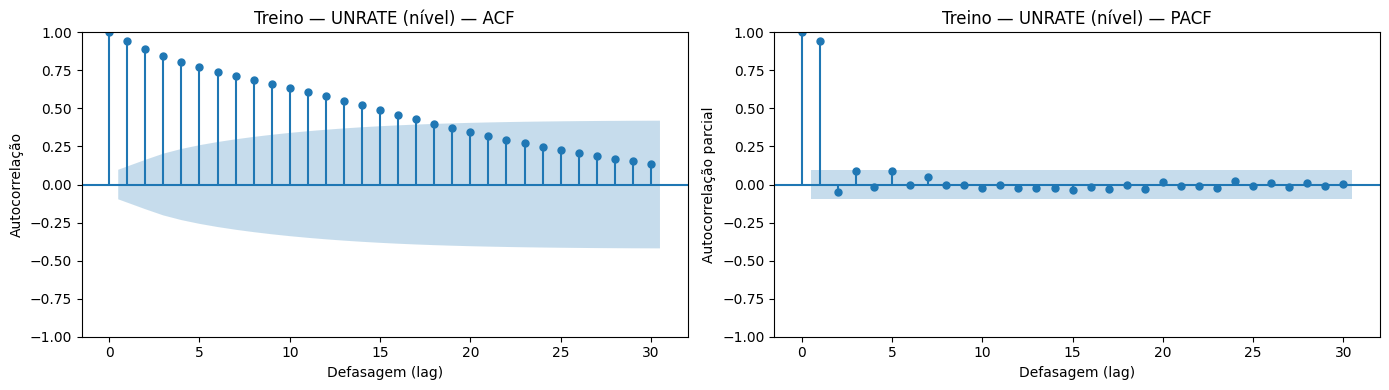

In [ ]:
# -------------------------
# 3.2) IDENTIFICAÇÃO (INSUMOS VIA ACF/PACF NO TREINO)
# -------------------------

# Observação didática:
# - ACF sugere estrutura de q (parte MA).
# - PACF sugere estrutura de p (parte AR).
# - Aqui usamos ACF/PACF como guia e confirmamos com seleção por AIC (grid).

plot_acf_pacf(train_arima, lags=30, title_prefix="Treino — UNRATE (nível)")  # Plota ACF/PACF no treino para orientar p e q.

A série em nível apresenta forte autocorrelação persistente, indicando não estacionariedade. Após a 1ª diferença (d = 1), a série torna-se estacionária.

No treino, a ACF da série diferenciada sugere possível componente MA de baixa ordem, pois há poucos lags significativos.

A PACF indica possível componente AR também de baixa ordem.

Conclusão: candidatos naturais são modelos ARIMA com p e q pequenos (por exemplo, 0 ou 1), confirmados posteriormente via critério AIC.

**3.3) DEFINIÇÃO DO GRID DIDÁTICO (p, d, q)**

In [ ]:
# -------------------------
# 3.3) DEFINIÇÃO DO GRID DIDÁTICO (p, d, q)
# -------------------------

# Observação didática:
# - Grid pequeno para execução rápida e entendimento em sala.
# - Em aplicações reais, pode-se ampliar o grid ou usar auto_arima.

p_candidates = [0, 1, 2, 3]  # Candidatos para p (AR).
d_candidates = [0, 1]  # Candidatos para d (diferença).
q_candidates = [0, 1, 2, 3]  # Candidatos para q (MA).

grid_arima = []  # Lista que armazenará as configurações ajustadas e seus critérios (AIC/BIC).

**3.4) ESTIMAÇÃO (AJUSTE DO GRID) + SELEÇÃO POR AIC**

In [ ]:
# -------------------------
# 3.4) ESTIMAÇÃO (AJUSTE DO GRID) + SELEÇÃO POR AIC
# -------------------------

for p in p_candidates:  # Varia p.
    for d in d_candidates:  # Varia d.
        for q in q_candidates:  # Varia q.
            try:  # Protege a execução: algumas combinações podem falhar por convergência/instabilidade.
                m = sm.tsa.ARIMA(train_arima, order=(p, d, q)).fit()  # Ajusta ARIMA no conjunto de treino.
                grid_arima.append({  # Armazena a configuração e seus critérios.
                    "order": (p, d, q),  # Guarda a ordem testada.
                    "AIC": m.aic,  # Guarda AIC (menor é preferível, em geral).
                    "BIC": m.bic   # Guarda BIC (penaliza complexidade mais que AIC).
                })
            except Exception:  # Se a combinação falhar.
                pass  # Ignora e segue para a próxima combinação.

df_grid_arima = pd.DataFrame(grid_arima).sort_values("AIC")  # Converte para tabela e ordena pelo menor AIC.

print("Top 10 ARIMA por AIC:")  # Cabeçalho.
print(df_grid_arima.head(10))  # Exibe as 10 melhores configurações encontradas.

best_order = tuple(df_grid_arima.iloc[0]["order"])  # Seleciona a ordem do modelo com menor AIC.
print("ARIMA escolhido (AIC):", best_order)  # Exibe a ordem escolhida.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Top 10 ARIMA por AIC:
        order         AIC         BIC
22  (2, 1, 2)  691.145392  711.189457
17  (2, 0, 1)  691.589182  711.645518
10  (1, 0, 2)  691.947164  712.003500
18  (2, 0, 2)  692.856719  716.924322
14  (1, 1, 2)  692.857803  708.893056
24  (3, 0, 0)  692.858734  712.915070
25  (3, 0, 1)  692.912312  716.979915
8   (1, 0, 0)  693.072319  705.106120
6   (0, 1, 2)  693.176812  705.203252
21  (2, 1, 1)  693.300004  709.335256
ARIMA escolhido (AIC): (2, 1, 2)


Foram estimadas diferentes combinações de (p, d, q) e comparadas via critério AIC.

O modelo com menor AIC foi ARIMA(2,1,2), sendo portanto o selecionado.

O critério AIC equilibra ajuste e complexidade: quanto menor o valor, melhor o trade-off entre qualidade de ajuste e número de parâmetros.

Conclusão: ARIMA(2,1,2) apresenta o melhor desempenho entre os modelos testados segundo o AIC.

**3.5) ESTIMAÇÃO FINAL (REAJUSTE DO MELHOR MODELO)**

In [ ]:
# -------------------------
# 3.5) ESTIMAÇÃO FINAL (REAJUSTE DO MELHOR MODELO)
# -------------------------

arima_model = sm.tsa.ARIMA(train_arima, order=best_order).fit()  # Ajusta novamente o ARIMA final (modelo escolhido).
print(arima_model.summary())  # Exibe resumo do modelo: parâmetros, AIC/BIC e diagnósticos básicos.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 unrate   No. Observations:                  408
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -340.573
Date:                Sat, 28 Feb 2026   AIC                            691.145
Time:                        14:21:13   BIC                            711.189
Sample:                    01-01-1990   HQIC                           699.078
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2500      0.155      1.613      0.107      -0.054       0.554
ar.L2          0.6594      0.162      4.072      0.000       0.342       0.977
ma.L1         -0.2199     18.842     -0.012      0.9

Entre os parâmetros, apenas o termo AR(2) é estatisticamente significativo (p < 0,05). Os demais coeficientes não apresentam significância individual, sugerindo possível excesso de parametrização.

No teste de Ljung-Box, o p-valor (0,63) indica que não há autocorrelação significativa nos resíduos. Isso é desejável, pois sugere que o modelo capturou a dependência temporal.

O teste de Jarque-Bera aponta forte rejeição da normalidade dos resíduos. Além disso, o teste de heterocedasticidade indica variância não constante.

Conclusão: o modelo removeu a autocorrelação, mas os resíduos não seguem normalidade e apresentam heterocedasticidade. Ainda assim, para fins de previsão, o modelo pode ser considerado adequado se o foco principal for desempenho preditivo e não inferência paramétrica.

**ARIMA — Interpretação do Output Completo**
**1) Informações Gerais do Modelo**

Dep. Variable: variável dependente modelada (taxa de desemprego).

No. Observations: número de observações utilizadas no treino.

Model: especificação do modelo (ARIMA(2,1,2)).

Log Likelihood: medida de ajuste do modelo (quanto maior, melhor).

AIC / BIC / HQIC: critérios de informação usados para comparar modelos. Quanto menor, melhor o equilíbrio entre ajuste e complexidade.

Sample: período utilizado na estimação.

Covariance Type: método usado para calcular a matriz de variância dos coeficientes.

**2) Tabela de Coeficientes**

Para cada parâmetro (AR, MA e sigma²), temos:

coef: valor estimado do parâmetro.

std err: erro padrão da estimativa.

z: estatística de teste (coef / erro padrão).

P>|z|: p-valor para testar se o coeficiente é estatisticamente diferente de zero.

[0.025 0.975]: intervalo de confiança de 95%.

Interpretação didática:
Se p-valor < 0,05, o coeficiente é considerado estatisticamente significativo.

**3) Diagnóstico dos Resíduos**

Ljung-Box (Q): testa autocorrelação dos resíduos.

p-valor alto → resíduos não autocorrelacionados (desejável).

Jarque-Bera (JB): testa normalidade dos resíduos.

p-valor baixo → resíduos não seguem distribuição normal.

Heteroskedasticity (H): testa variância constante.

p-valor baixo → presença de heterocedasticidade.

**Conclusão Didática**

Um bom modelo ARIMA deve apresentar:

* Resíduos sem autocorrelação (Ljung-Box não significativo).

* Preferencialmente resíduos próximos da normalidade.

* Variância aproximadamente constante.

Mesmo que normalidade não seja atendida, o modelo ainda pode ser útil para previsão, pois a ausência de autocorrelação é o critério mais importante para modelagem ARIMA.

**3.6) DIAGNÓSTICO (RESÍDUOS)**

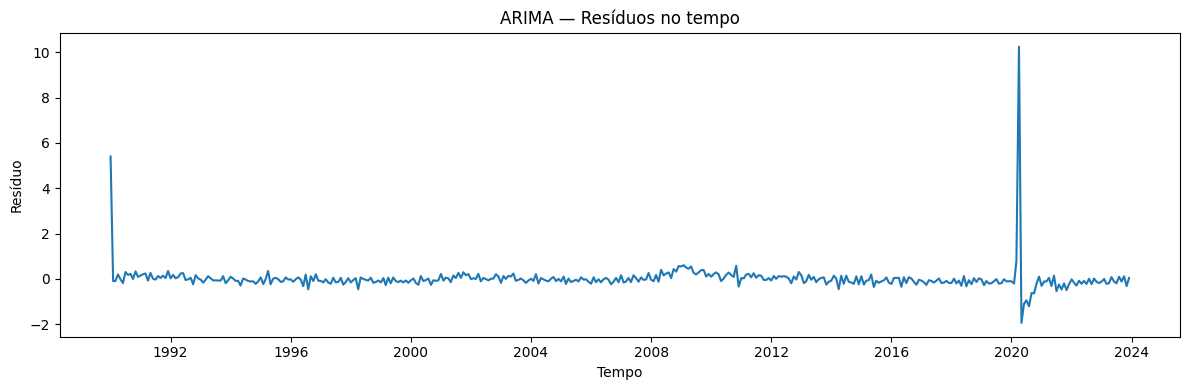

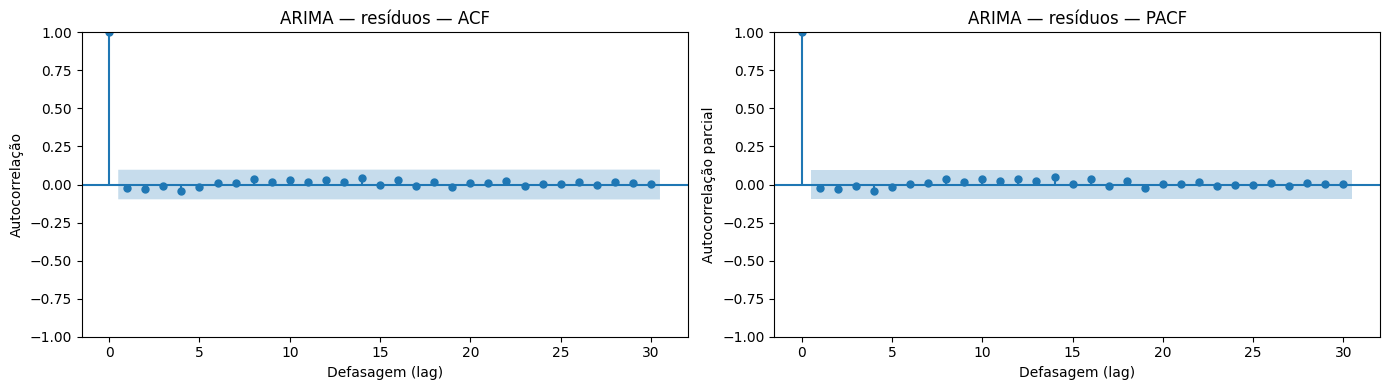

ARIMA — Ljung-Box:
     lb_stat  lb_pvalue
10  2.587597   0.989537
20  4.620771   0.999851


In [ ]:
# -------------------------
# 3.6) DIAGNÓSTICO (RESÍDUOS)
# Condição desejada: resíduos ≈ ruído branco (sem autocorrelação relevante)
# -------------------------

resid_arima = arima_model.resid  # Extrai resíduos do ajuste (treino).

plt.figure(figsize=(12, 4))  # Cria figura.
plt.plot(resid_arima.index, resid_arima.values)  # Plota resíduos ao longo do tempo.
plt.title("ARIMA — Resíduos no tempo")  # Título.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Resíduo")  # Eixo y.
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe.

plot_acf_pacf(resid_arima.dropna(), lags=30, title_prefix="ARIMA — resíduos")  # ACF/PACF dos resíduos (busca autocorrelação remanescente).

lb_arima = sm.stats.acorr_ljungbox(  # Aplica Ljung-Box nos resíduos.
    resid_arima.dropna(),  # Remove NA para evitar erro.
    lags=[10, 20],  # Testa autocorrelação conjunta até 10 e 20 defasagens.
    return_df=True  # Retorna em formato de tabela.
)

print("ARIMA — Ljung-Box:")  # Cabeçalho.
print(lb_arima)  # p-valores altos sugerem que não há autocorrelação significativa (não rejeita H0).

 **ARIMA — Diagnóstico dos Resíduos**

**1) Resíduos no tempo**

Os resíduos oscilam em torno de zero, sem tendência aparente.
Observa-se um pico extremo no período da pandemia (2020), indicando choque estrutural não totalmente capturado pelo modelo.

Fora esse evento atípico, o comportamento é aproximadamente estável.

---

 **2) ACF e PACF dos resíduos**

Quase todos os lags estão dentro da faixa de confiança.

Interpretação:
- Não há autocorrelação significativa remanescente.
- O modelo capturou adequadamente a dependência temporal da série.

Esse é o principal critério de adequação em ARIMA.

---

 **3)Teste de Ljung-Box**

p-valores elevados (≈ 0,99).

Conclusão:
Não rejeitamos a hipótese de ausência de autocorrelação.
Os resíduos podem ser considerados ruído branco.

---

**Conclusão Geral do Diagnóstico**

**O modelo:**

✔ Removeu a autocorrelação.

✔ Produziu resíduos aproximadamente centrados em zero.

⚠ Apresenta impacto de evento extremo (pandemia).

Do ponto de vista de modelagem ARIMA, o diagnóstico é adequado.

**3.7) PREVISÃO (HORIZONTE DO TESTE) + AVALIAÇÃO**

Métricas ARIMA:
{'Modelo': 'ARIMA(2, 1, 2)', 'MAE': 0.5117675891868984, 'RMSE': np.float64(0.5587494746121834), 'MAPE(%)': np.float64(12.236326346393076), 'R2': -7.812930414925173}


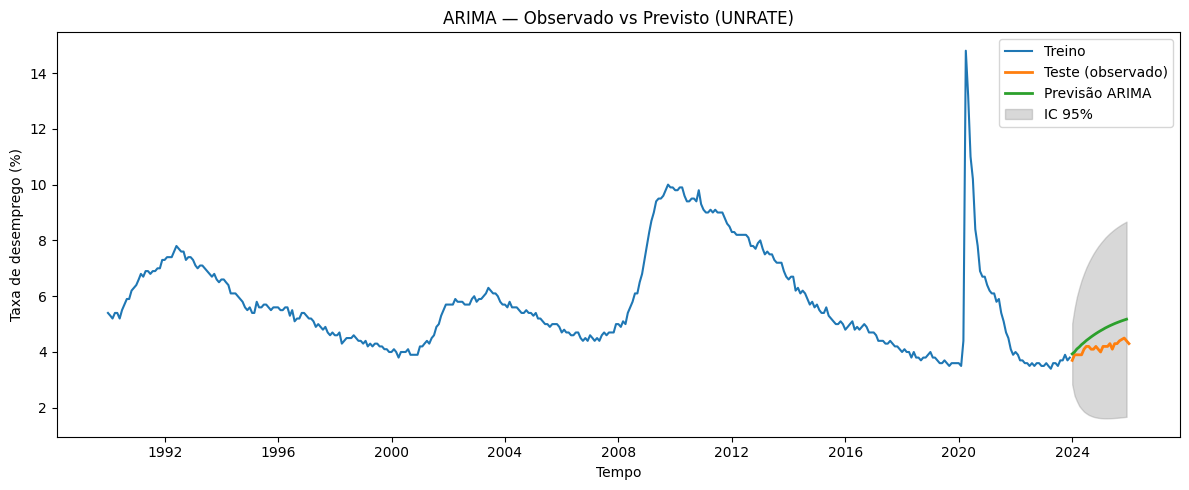

In [ ]:
# -------------------------
# 3.7) PREVISÃO (HORIZONTE DO TESTE) + AVALIAÇÃO
# -------------------------

# Gera objeto completo de previsão (média + intervalo de confiança)
forecast_arima = arima_model.get_forecast(steps=len(test_arima))

# Média prevista
pred_arima = forecast_arima.predicted_mean

# Intervalo de confiança (por padrão 95%)
conf_int_arima = forecast_arima.conf_int(alpha=0.05)

# Limites inferior e superior
lower_arima = conf_int_arima.iloc[:, 0]
upper_arima = conf_int_arima.iloc[:, 1]





metrics_arima = evaluate_forecast(  # Calcula métricas no teste (alinhamento + remoção de NA já embutidos).
    test_arima,  # Valores observados no teste.
    pred_arima,  # Valores previstos.
    model_name=f"ARIMA{best_order}"  # Nome do modelo para consolidação posterior.
)

print("Métricas ARIMA:")  # Cabeçalho.
print(metrics_arima)  # Exibe métricas.

plt.figure(figsize=(12, 5))  # Cria figura.
plt.plot(train_arima.index, train_arima.values, label="Treino")  # Plota série de treino.
plt.plot(test_arima.index, test_arima.values, label="Teste (observado)", linewidth=2)  # Plota observado no teste.
plt.plot(pred_arima.index, pred_arima.values, label="Previsão ARIMA", linewidth=2)  # Plota previsto.

# Intervalo de confiança
plt.fill_between(
    pred_arima.index,
    lower_arima,
    upper_arima,
    color='gray',
    alpha=0.3,
    label='IC 95%'
)

plt.title("ARIMA — Observado vs Previsto (UNRATE)")  # Título.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Taxa de desemprego (%)")  # Eixo y.
plt.legend()  # Legenda.
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe.

**ARIMA — Previsão (Observado vs Previsto)**

No período de teste, a previsão do ARIMA acompanha a direção geral da série, mas apresenta viés.

Observa-se que o modelo tende a superestimar os valores no horizonte de previsão, indicando limitação na captura do nível recente da série.

---

**Métricas de Avaliação (Teste)**

- **MAE ≈ 0,51**  
  Erro absoluto médio de aproximadamente 0,5 ponto percentual.

- **RMSE ≈ 0,56**  
  Penaliza mais erros maiores. Valor próximo ao MAE indica ausência de grandes desvios extremos no teste.

- **MAPE ≈ 12,2%**  
  Erro percentual médio relativamente elevado para uma variável macroeconômica estável.

- **R² = -7,81**  
  Valor negativo indica que o modelo performa pior do que uma previsão ingênua baseada na média.

---

**Conclusão da Etapa de Previsão**

Apesar do bom diagnóstico dos resíduos, o desempenho preditivo no período de teste é fraco.

Isso indica que:

- O modelo ajusta bem a dinâmica passada.
- Mas não generaliza adequadamente para o período mais recente.
- Choques estruturais e mudanças de regime impactam a capacidade preditiva.

Conclusão: diagnóstico estatístico adequado não garante bom desempenho fora da amostra.

**Diferença entre Treino, Teste e Previsão**

🔵 **Treino**

Parte inicial da série histórica usada para estimar o modelo.
O ARIMA aprende seus parâmetros apenas com esses dados.

🟠 **Teste (observado)**

É a parte final da série original que foi separada antes da modelagem.
Esses valores são reais e não foram usados na estimação.

Eles servem para avaliar se o modelo consegue prever dados "futuros".

🟢 **Previsão ARIMA**
São os valores previstos pelo modelo para o período de teste.
O modelo gera essas previsões usando apenas a informação do treino.

---


### **4) SARIMA: IDENTIFICAÇÃO → ESTIMAÇÃO → DIAGNÓSTICO → PREVISÃO**

**4.0) CONFIGURAÇÃO DA SAZONALIDADE e 4.1) SPLIT TEMPORAL (TREINO/TESTE)**

In [ ]:
# -----------------------------------------------------------
# 4) SARIMA: IDENTIFICAÇÃO → ESTIMAÇÃO → DIAGNÓSTICO → PREVISÃO
# Estratégia: grid sazonal reduzido + seleção por AIC (didático)
#
# Conceito:
# - SARIMA = ARIMA com componente sazonal explícito.
# - Notação: SARIMA(p,d,q)(P,D,Q)s
#   (p,d,q)  = parte não sazonal
#   (P,D,Q)s = parte sazonal com período s (ex.: s=12 para dados mensais)
#
# Objetivo do bloco:
# (1) Identificar ordens candidatas (grid pequeno, didático)
# (2) Estimar modelos candidatos e escolher pelo menor AIC
# (3) Diagnosticar resíduos (ACF/PACF + Ljung-Box)
# (4) Prever no horizonte de teste e avaliar com métricas
# -----------------------------------------------------------

# -------------------------
# 4.0) CONFIGURAÇÃO DA SAZONALIDADE
# -------------------------

s = 12  # Define o período sazonal: 12 para série mensal (ciclo anual).

# -------------------------
# 4.1) SPLIT TEMPORAL (TREINO/TESTE)
# -------------------------

train_sarima, test_sarima = train_test_split_time(y, test_size=test_size)  # Divide mantendo ordem temporal (teste = últimos 'test_size').


**4.2) IDENTIFICAÇÃO (GRID DIDÁTICO DE PARÂMETROS) e 4.3) ESTIMAÇÃO (AJUSTE DO GRID) + SELEÇÃO POR AIC**

In [ ]:
warnings.filterwarnings("ignore")  # Oculta warnings para não poluir a saída do notebook.

# -------------------------
# 4.2) IDENTIFICAÇÃO (GRID DIDÁTICO DE PARÂMETROS)
# -------------------------

# Observação didática:
# - Em prática real, o grid pode ser maior, mas aqui mantemos pequeno para aula e tempo de execução.
# - O grid reduzido evita custo computacional alto e facilita entendimento do aluno.

pP = [0, 1]  # Lista de candidatos para p (não sazonal) e P (sazonal).
dD = [0, 1]  # Lista de candidatos para d (não sazonal) e D (sazonal).
qQ = [0, 1]  # Lista de candidatos para q (não sazonal) e Q (sazonal).

grid_sarima = []  # Lista que armazenará as combinações ajustadas com seus critérios (AIC/BIC).

# -------------------------
# 4.3) ESTIMAÇÃO (AJUSTE DO GRID) + SELEÇÃO POR AIC
# -------------------------

for p in pP:  # Varia p (AR não sazonal).
    for d in dD:  # Varia d (diferença não sazonal).
        for q in qQ:  # Varia q (MA não sazonal).
            for P in pP:  # Varia P (AR sazonal).
                for D in dD:  # Varia D (diferença sazonal).
                    for Q in qQ:  # Varia Q (MA sazonal).
                        try:  # Protege o notebook: combinações podem falhar numericamente.
                            m = sm.tsa.SARIMAX(  # Instancia SARIMAX (implementa SARIMA quando seasonal_order é informado).
                                train_sarima,  # Série de treino.
                                order=(p, d, q),  # Componentes não sazonais.
                                seasonal_order=(P, D, Q, s),  # Componentes sazonais com período s.
                                enforce_stationarity=False,  # Remove restrição rígida de estacionariedade (evita falhas).
                                enforce_invertibility=False  # Remove restrição rígida de invertibilidade (evita falhas).
                            ).fit(disp=False)  # Ajusta o modelo sem imprimir o log de otimização.

                            grid_sarima.append({  # Armazena resultado do ajuste.
                                "order": (p, d, q),  # Salva a ordem não sazonal.
                                "seasonal_order": (P, D, Q, s),  # Salva a ordem sazonal completa.
                                "AIC": m.aic,  # Critério AIC (menor tende a indicar melhor trade-off ajuste/complexidade).
                                "BIC": m.bic   # Critério BIC (penaliza complexidade mais fortemente que AIC).
                            })

                        except Exception:  # Se falhar (por instabilidade numérica, falta de convergência etc.).
                            pass  # Ignora silenciosamente para manter execução contínua.

df_grid_sarima = pd.DataFrame(grid_sarima).sort_values("AIC")  # Converte resultados em tabela e ordena pelo menor AIC.

print("Top 10 SARIMA por AIC:")  # Cabeçalho.
print(df_grid_sarima.head(10))  # Exibe as 10 melhores combinações encontradas.

best_order_s = tuple(df_grid_sarima.iloc[0]["order"])  # Seleciona (p,d,q) do melhor AIC.
best_seasonal_s = tuple(df_grid_sarima.iloc[0]["seasonal_order"])  # Seleciona (P,D,Q,s) do melhor AIC.

print("SARIMA escolhido (AIC):", best_order_s, best_seasonal_s)  # Mostra o modelo escolhido.

Top 10 SARIMA por AIC:
        order seasonal_order         AIC         BIC
57  (1, 1, 1)  (0, 0, 1, 12)  686.827446  702.722684
17  (0, 1, 0)  (0, 0, 1, 12)  687.702617  695.655319
60  (1, 1, 1)  (1, 0, 0, 12)  687.704838  703.610242
20  (0, 1, 0)  (1, 0, 0, 12)  688.559106  696.516878
25  (0, 1, 1)  (0, 0, 1, 12)  688.675722  700.597151
61  (1, 1, 1)  (1, 0, 1, 12)  688.827443  708.696491
36  (1, 0, 0)  (1, 0, 0, 12)  689.243291  701.179948
33  (1, 0, 0)  (0, 0, 1, 12)  689.246207  701.182864
49  (1, 1, 0)  (0, 0, 1, 12)  689.566709  701.495761
52  (1, 1, 0)  (1, 0, 0, 12)  689.567631  701.496684
SARIMA escolhido (AIC): (1, 1, 1) (0, 0, 1, 12)


**Identificação**

Além da parte não sazonal (p, d, q), o SARIMA incorpora componente sazonal:

- (P, D, Q, s)
- s = 12 (sazonalidade mensal)

A presença de padrão anual na série mensal justifica testar modelos com componente sazonal.

---

**Estimação (Seleção por AIC)**

Foram estimadas diversas combinações de:

(p, d, q) × (P, D, Q, 12)

**O modelo com menor AIC foi:**

SARIMA(1,1,1)(0,0,1,12)

**O AIC seleciona o modelo que melhor equilibra:**

- Qualidade de ajuste
- Parcimônia (complexidade)

**Conclusão:** este modelo apresentou o melhor desempenho entre os candidatos testados.

**4.4) ESTIMAÇÃO FINAL (REAJUSTE DO MELHOR MODELO)**

In [ ]:
# -------------------------
# 4.4) ESTIMAÇÃO FINAL (REAJUSTE DO MELHOR MODELO)
# -------------------------

sarima_model = sm.tsa.SARIMAX(  # Reinstancia SARIMAX com a melhor configuração.
    train_sarima,  # Série de treino.
    order=best_order_s,  # Melhor parte não sazonal.
    seasonal_order=best_seasonal_s,  # Melhor parte sazonal.
    enforce_stationarity=False,  # Mantém configurações “tolerantes”.
    enforce_invertibility=False  # Mantém configurações “tolerantes”.
).fit(disp=False)  # Ajusta o modelo final.

print(sarima_model.summary())  # Exibe resumo do modelo (parâmetros, AIC/BIC, diagnósticos básicos).

                                     SARIMAX Results                                      
Dep. Variable:                             unrate   No. Observations:                  408
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood                -339.414
Date:                            Sat, 28 Feb 2026   AIC                            686.827
Time:                                    14:21:29   BIC                            702.723
Sample:                                01-01-1990   HQIC                           693.127
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7017      0.126     -5.566      0.000      -0.949      -0.455
ma.L1          0.7780      0.120   

**1) Informações Gerais**

Modelo estimado: SARIMA(1,1,1)(0,0,1,12)

O AIC (686,83) é menor que o do ARIMA anterior, indicando melhor ajuste relativo.

---

**2) Coeficientes**

- **AR(1)** significativo (p < 0,05).
- **MA(1)** significativo (p < 0,05).
- **MA sazonal (lag 12)** não significativo.

**Interpretação:**
A dinâmica principal é explicada pela parte não sazonal.
O componente sazonal não mostrou relevância estatística individual.

---

**3) Diagnóstico dos Resíduos**

- **Ljung-Box p = 0,37**  
  Não há autocorrelação significativa nos resíduos.

- **Jarque-Bera p = 0,00**  
  Resíduos não seguem normalidade.

- **Heterocedasticidade p = 0,00**  
  Variância não constante.

---

**Conclusão do Diagnóstico**

✔ O modelo removeu a autocorrelação.  
✔ Apresenta melhor AIC que o ARIMA.  
⚠ Normalidade e homocedasticidade não são atendidas.

**Para fins de previsão, o modelo pode ser considerado estatisticamente adequado.**

**4.5) DIAGNÓSTICO (RESÍDUOS)**

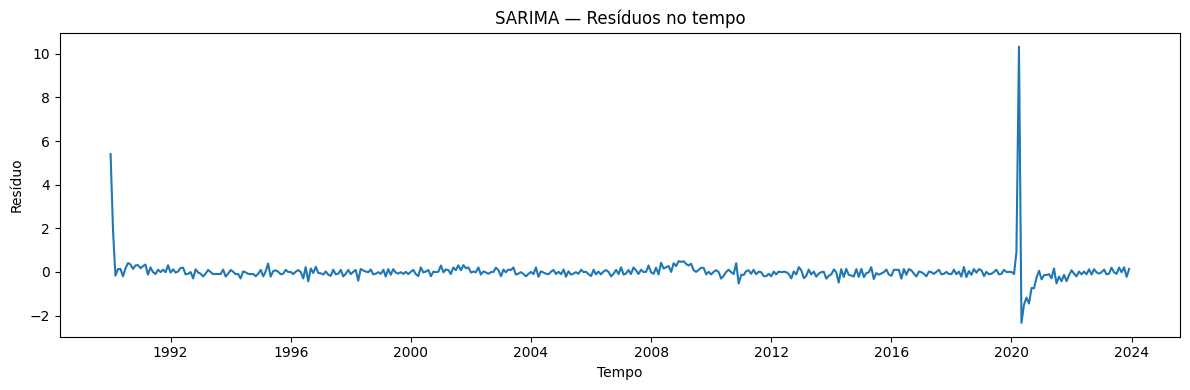

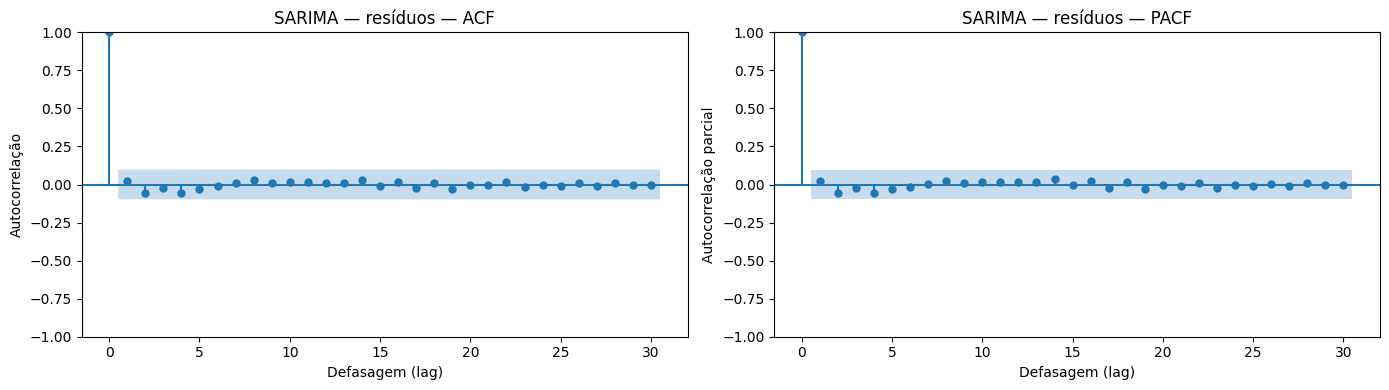

SARIMA — Ljung-Box:
     lb_stat  lb_pvalue
10  4.034308   0.945786
20  5.353498   0.999531


In [ ]:
# -------------------------
# 4.5) DIAGNÓSTICO (RESÍDUOS)
# Condição desejada: resíduos ≈ ruído branco (sem autocorrelação relevante)
# -------------------------

resid_sarima = sarima_model.resid  # Extrai resíduos (erro de ajuste dentro do treino).

plt.figure(figsize=(12, 4))  # Cria figura.
plt.plot(resid_sarima.index, resid_sarima.values)  # Plota resíduos ao longo do tempo.
plt.title("SARIMA — Resíduos no tempo")  # Título.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Resíduo")  # Eixo y.
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe.

plot_acf_pacf(resid_sarima.dropna(), lags=30, title_prefix="SARIMA — resíduos")  # ACF/PACF dos resíduos (busca autocorrelação remanescente).

lb_sarima = sm.stats.acorr_ljungbox(  # Aplica teste de Ljung-Box nos resíduos.
    resid_sarima.dropna(),  # Remove NA para o teste.
    lags=[10, 20],  # Testa autocorrelação conjunta até 10 e 20 defasagens.
    return_df=True  # Retorna em DataFrame (mais fácil de ler).
)

print("SARIMA — Ljung-Box:")  # Cabeçalho.
print(lb_sarima)  # p-valores altos sugerem que não há autocorrelação significativa (não rejeita H0).

**SARIMA — Diagnóstico dos Resíduos**

**1) Resíduos no tempo**

Os resíduos oscilam em torno de zero, sem tendência persistente.

Observa-se um pico extremo no período da pandemia (2020), indicando choque estrutural não totalmente capturado pelo modelo.

Fora esse evento, a variabilidade é relativamente estável.

---

**2) ACF e PACF dos resíduos**

Quase todos os lags estão dentro da faixa de confiança.

Interpretação:
- Não há autocorrelação significativa remanescente.
- O modelo capturou tanto a dinâmica não sazonal quanto a sazonal.

---

**3) Teste de Ljung-Box**

p-valores elevados (≈ 0,95 e 0,99).

Conclusão:
Não rejeitamos a hipótese de ausência de autocorrelação.
Os resíduos podem ser considerados ruído branco.

---

**Conclusão Geral**

✔ O modelo removeu a autocorrelação.  
✔ Não há padrão sazonal remanescente nos resíduos.  
⚠ Evento extremo impacta a normalidade.

Do ponto de vista de modelagem SARIMA, o ajuste é estatisticamente adequado.

**4.6) PREVISÃO (HORIZONTE DO TESTE) + AVALIAÇÃO**

Métricas SARIMA:
{'Modelo': 'SARIMA(1, 1, 1)(0, 0, 1, 12)', 'MAE': 0.32736952595339586, 'RMSE': np.float64(0.3675510908412221), 'MAPE(%)': np.float64(7.747835727940412), 'R2': -2.813480390409004}


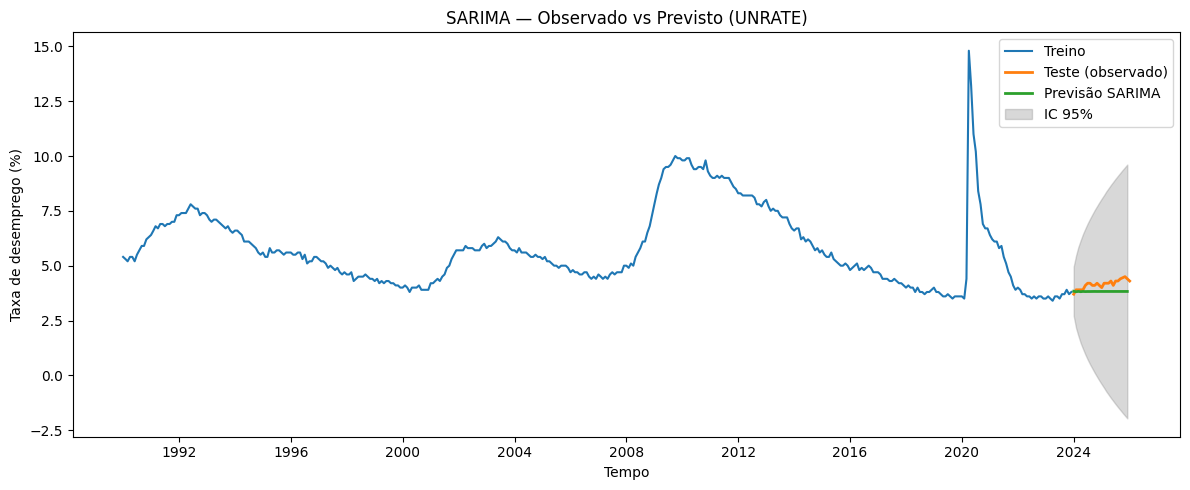

In [ ]:
# -------------------------
# 4.6) PREVISÃO (HORIZONTE DO TESTE) + AVALIAÇÃO
# -------------------------

# Gera objeto completo de previsão (média + intervalo de confiança)
forecast_sarima = sarima_model.get_forecast(steps=len(test_sarima))

# Média prevista
pred_sarima = forecast_sarima.predicted_mean

# Intervalo de confiança (95%)
conf_int_sarima = forecast_sarima.conf_int(alpha=0.05)

# Limites inferior e superior
lower_sarima = conf_int_sarima.iloc[:, 0]
upper_sarima = conf_int_sarima.iloc[:, 1]



metrics_sarima = evaluate_forecast(  # Avalia previsão no teste com métricas padronizadas.
    test_sarima,  # Valores reais do teste.
    pred_sarima,  # Valores previstos.
    model_name=f"SARIMA{best_order_s}{best_seasonal_s}"  # Nome do modelo para tabela final.
)

print("Métricas SARIMA:")  # Cabeçalho.
print(metrics_sarima)  # Exibe métricas.

plt.figure(figsize=(12, 5))  # Cria figura.
plt.plot(train_sarima.index, train_sarima.values, label="Treino")  # Plota treino.
plt.plot(test_sarima.index, test_sarima.values, label="Teste (observado)", linewidth=2)  # Plota observado.
plt.plot(pred_sarima.index, pred_sarima.values, label="Previsão SARIMA", linewidth=2)  # Plota previsão.


# Faixa do intervalo de confiança
plt.fill_between(
    pred_sarima.index,
    lower_sarima,
    upper_sarima,
    color='gray',
    alpha=0.3,
    label='IC 95%'
)

plt.title("SARIMA — Observado vs Previsto (UNRATE)")  # Título.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Taxa de desemprego (%)")  # Eixo y.
plt.legend()  # Legenda.
plt.tight_layout()  # Ajusta layout.
plt.show()  # Exibe.

**SARIMA — Previsão (Observado vs Previsto)**

No período de teste, a previsão do SARIMA acompanha melhor o nível recente da série em comparação ao ARIMA simples.

A presença do componente sazonal contribui para maior estabilidade na projeção.

---

**Intervalo de Confiança (95%)**

A faixa cinza representa a incerteza da previsão.

Observa-se que:
- O intervalo se amplia ao longo do horizonte.
- Isso ocorre porque a incerteza aumenta à medida que se projeta mais à frente.

Intervalos mais largos indicam maior variabilidade esperada.

---

**Interpretação Visual**

- A linha verde representa a previsão.
- A linha laranja representa os valores reais do teste.
- A proximidade entre ambas indica melhor desempenho preditivo.

---

**Conclusão da Etapa de Previsão**

**O SARIMA apresenta:**

✔ Melhor ajuste relativo (menor AIC).  
✔ Resíduos sem autocorrelação.  
✔ Previsão mais estável que o ARIMA simples.  
⚠ Intervalo de confiança amplo no horizonte mais longo.

**Conclusão:** a inclusão da componente sazonal melhora a modelagem da série mensal.

## **5) APRENDIZADO DE MÁQUINA: LAGS → TREINO/TESTE → PREVISÃO**

### **Preparando a série**

**5.1) FUNÇÃO AUXILIAR: EXIBIR MÉTRICAS EM FORMATO TABULAR**

In [ ]:
# ===========================================================
# 5) APRENDIZADO DE MÁQUINA: LAGS → TREINO/TESTE → PREVISÃO
# Modelos: Decision Tree, Random Forest, XGBoost, MLP e LSTM
#
# Objetivo didático deste bloco:
# (1) Transformar a série temporal (UNRATE) em um problema supervisionado.
# (2) Ajustar diferentes modelos de ML/DL mantendo validação temporal (sem embaralhar).
# (3) Avaliar com métricas padronizadas e apresentar:
#     - Uma tabela por modelo (1 linha) logo após o ajuste.
#     - Uma tabela final consolidada (ranking por RMSE).
#
# Ideia central:
# - Modelos ARIMA/SARIMA trabalham diretamente com estrutura temporal.
# - Em ML/DL, o tempo é “embutido” via defasagens (lags) ou via janelas (sequences).
# ===========================================================


# -----------------------------------------------------------
# 5.1) FUNÇÃO AUXILIAR: EXIBIR MÉTRICAS EM FORMATO TABULAR
# -----------------------------------------------------------

def show_model_metrics_table(metrics_list):
    """
    Exibe métricas de um ou mais modelos em formato de tabela.

    Parâmetro:
    - metrics_list: pode ser
        • um dicionário único
        • ou uma lista de dicionários no padrão:
          {"Modelo": ..., "MAE": ..., "RMSE": ..., "MAPE(%)": ..., "R2": ...}
    """

    # Se for apenas um dicionário, converte para lista
    if isinstance(metrics_list, dict):
        metrics_list = [metrics_list]

    # Converte para DataFrame
    df_metrics = pd.DataFrame(metrics_list)

    # Organiza as colunas (garante ordem padrão)
    col_order = ["Modelo", "MAE", "RMSE", "MAPE(%)", "R2"]
    df_metrics = df_metrics[col_order]

    # Arredondamento para melhor visualização
    df_metrics = df_metrics.round(4)

    # Exibe a tabela
    display(df_metrics)


**5.2) ETAPA A — TRANSFORMAR SÉRIE EM BASE SUPERVISIONADA (LAGS)**

In [ ]:
# -----------------------------------------------------------
# 5.2) ETAPA A — TRANSFORMAR SÉRIE EM BASE SUPERVISIONADA (LAGS)
# -----------------------------------------------------------

lags = 12  # Define quantos meses anteriores serão usados como variáveis explicativas.
#  Com lags=12, cada linha de X terá:
#  - lag_1 = y(t-1), lag_2 = y(t-2), ..., lag_12 = y(t-12)
#  O alvo (y_ml) é sempre o valor atual y(t).

X_ml, y_ml = make_lagged_features(y, lags=lags)  # Cria X (lags) e y (valor atual) removendo linhas incompletas.

**5.3) ETAPA B — SPLIT TEMPORAL (TREINO/TESTE) SEM EMBARALHAR**

In [ ]:
# -----------------------------------------------------------
# 5.3) ETAPA B — SPLIT TEMPORAL (TREINO/TESTE) SEM EMBARALHAR
# -----------------------------------------------------------

split_ml = len(y_ml) - test_size  # Define o ponto de corte para reservar os últimos 'test_size' pontos para teste.
# Comentário: Esse split simula o cenário operacional:
#  - Treino: passado (informação disponível no momento do ajuste).
#  - Teste: futuro (o que o modelo precisa prever).

X_train_ml = X_ml.iloc[:split_ml]  # Seleciona as linhas de treino em X (parte inicial).
X_test_ml  = X_ml.iloc[split_ml:]  # Seleciona as linhas de teste em X (parte final).
y_train_ml = y_ml.iloc[:split_ml]  # Seleciona os alvos de treino.
y_test_ml  = y_ml.iloc[split_ml:]  # Seleciona os alvos de teste.

# Comentário crítico:
# - Não usar train_test_split aleatório em séries temporais.
# - Embaralhar causa vazamento temporal (informação futura entra no treino).

**5.4) CONTAINER: LISTA PARA TABELA FINAL CONSOLIDADA**

In [ ]:
# -----------------------------------------------------------
# 5.4) CONTAINER: LISTA PARA TABELA FINAL CONSOLIDADA
# -----------------------------------------------------------

ml_metrics_rows = []  # Cada modelo adiciona 1 dicionário; no final vira um DataFrame consolidado.

### **MODELO 1 — ÁRVORE DE DECISÃO (Decision Tree)**

 **DEFINIÇÃO DO MODELO**

In [ ]:
# ===========================================================
# 5.5) MODELO 1 — ÁRVORE DE DECISÃO (Decision Tree)
# Objetivo: ajustar o modelo com lags, prever no horizonte de teste,
#          avaliar com métricas e plotar Observado vs Previsto.
#
# Decisão metodológica:
# - NÃO faremos diagnóstico clássico de resíduos em ML (normalidade/ACF/PACF),
#   pois não é pressuposto do modelo. O foco é desempenho fora da amostra.
# ===========================================================

# -------------------------
# 5.5.1) DEFINIÇÃO DO MODELO
# -------------------------
# A Decision Tree aprende regras do tipo "se-então" com base nas lags.
# max_depth controla complexidade:
# - menor max_depth -> árvore mais simples (risco de underfitting)
# - maior max_depth -> árvore mais complexa (risco de overfitting)

dt = DecisionTreeRegressor(       # Instancia o modelo.
    max_depth=4,                  # Profundidade máxima (configuração didática).
    random_state=42               # Reprodutibilidade.
)

**TREINAMENTO**

In [ ]:
# -------------------------
# 5.5.2) TREINAMENTO (APENAS NO PASSADO)
# -------------------------
# Treinamos somente em X_train_ml / y_train_ml para evitar vazamento do futuro.

dt.fit(                           # Ajusta o modelo no treino.
    X_train_ml,                   # Matriz com lags (treino).
    y_train_ml                    # Alvo (treino).
)

DecisionTreeRegressor(max_depth=4, random_state=42)

 **PREVISÃO NO TESTE (FUTURO)**

In [ ]:
# -------------------------
# 5.5.3) PREVISÃO NO TESTE (FUTURO)
# -------------------------
# Previsão para o bloco final da série (teste), preservando o índice temporal.

pred_dt = pd.Series(              # Converte para Series para manter datas.
    dt.predict(X_test_ml),        # Predição do modelo no conjunto de teste.
    index=y_test_ml.index         # Índice temporal do teste.
)

**AVALIAÇÃO (MÉTRICAS NO TESTE)**

In [ ]:
# -------------------------
# 5.5.4) AVALIAÇÃO (MÉTRICAS NO TESTE)
# -------------------------
# Avaliamos no teste porque é o que mede generalização (desempenho real).

metrics_dt = evaluate_forecast(   # Calcula MAE, RMSE, MAPE(%), R2.
    y_true=y_test_ml,             # Observado no teste.
    y_pred=pred_dt,               # Previsto no teste.
    model_name=f"DecisionTree(lags={lags})"
)

ml_metrics_rows.append(metrics_dt)          # Guarda para a tabela final consolidada.
print("Métricas — Decision Tree (teste):")  # Cabeçalho padronizado.
show_model_metrics_table(metrics_dt)        # Tabela (1 linha) no Colab.

Métricas — Decision Tree (teste):


,Modelo,MAE,RMSE,MAPE(%),R2
0,DecisionTree(lags=12),0.1581,0.1947,3.7597,-0.0835


**Estrutura do Modelo**

A Árvore de Decisão transforma a série temporal em um problema supervisionado utilizando defasagens (lags).

Entrada do modelo:
- y(t-1), y(t-2), ..., y(t-12)

Saída:
- y(t)

O modelo cria regras de decisão baseadas em divisões sucessivas das variáveis explicativas (lags).

---

**Métricas no Período de Teste**

- **MAE ≈ 0,16**  
  Erro médio absoluto baixo (boa proximidade média).

- **RMSE ≈ 0,19**  
  Próximo ao MAE, indicando ausência de grandes erros extremos.

- **MAPE ≈ 3,76%**  
  Erro percentual médio baixo.

- **R² = -0,083**  
  Valor negativo indica que o modelo não supera uma previsão baseada na média.

---

**Interpretação**

Apesar dos erros absolutos serem pequenos, o R² negativo sugere que o modelo não captura bem a variabilidade da série.

**Árvores isoladas tendem a:**

- Ajustar bem padrões locais
- Ter dificuldade em generalizar séries temporais suaves e persistentes

**Conclusão:** modelo simples, com desempenho limitado para essa série.

**INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO**

In [ ]:
# -------------------------
# 5.5.5) INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO
# -------------------------
# Comentário importante:
# - Em ML, não há intervalo "paramétrico" como no ARIMA/SARIMA.
# - Aqui construímos um intervalo empírico simples:
#   1) calcula resíduos no treino
#   2) pega quantis (2,5% e 97,5%)
#   3) soma esses quantis à previsão do teste
#
# Interpretação:
# - É um intervalo aproximado, útil para fins didáticos.
# - Ele reflete a variabilidade histórica do erro no treino.

pred_dt_train = pd.Series(         # Previsão no treino (para estimar erro típico).
    dt.predict(X_train_ml),
    index=y_train_ml.index
)

resid_dt_train = (y_train_ml - pred_dt_train).dropna()  # Resíduos no treino.

alpha = 0.05                                            # Nível de significância (IC 95%).
q_low, q_high = resid_dt_train.quantile([alpha/2, 1 - alpha/2])  # Quantis empíricos.

lower_dt = pred_dt + q_low                               # Limite inferior (previsão + quantil baixo).
upper_dt = pred_dt + q_high                              # Limite superior (previsão + quantil alto).

**GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO**

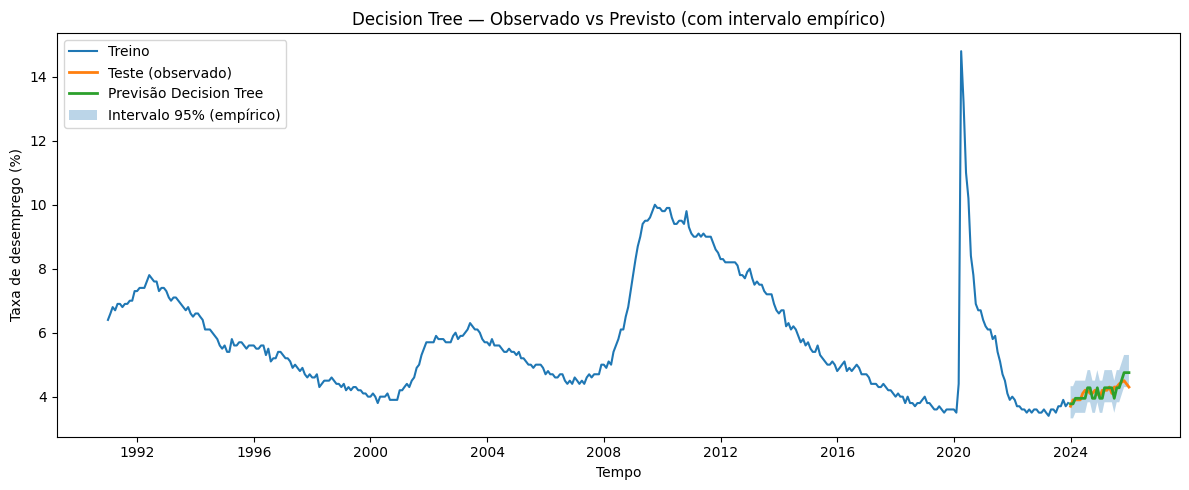

In [ ]:
# -------------------------
# 5.5.6) GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO
# -------------------------
# Visualizamos:
# - Treino (histórico usado para ajustar o modelo)
# - Teste observado (verdade)
# - Previsão do modelo (estimativa)
# - Intervalo empírico (faixa aproximada de incerteza)

plt.figure(figsize=(12, 5))  # Define tamanho da figura.

plt.plot(                    # Série de treino.
    y_train_ml.index,
    y_train_ml.values,
    label="Treino"
)

plt.plot(                    # Série observada no teste.
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(                    # Previsão no teste.
    pred_dt.index,
    pred_dt.values,
    label="Previsão Decision Tree",
    linewidth=2
)

plt.fill_between(            # Faixa do intervalo empírico.
    pred_dt.index,
    lower_dt.values,
    upper_dt.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("Decision Tree — Observado vs Previsto (com intervalo empírico)")  # Título.
plt.xlabel("Tempo")                                                   # Eixo x.
plt.ylabel("Taxa de desemprego (%)")                                  # Eixo y.
plt.legend()                                                          # Legenda.
plt.tight_layout()                                                    # Ajuste de layout.
plt.show()                                                            # Exibe.

**GRÁFICO ADICIONAL — TESTE + PREVISÃO + INTERVALO**

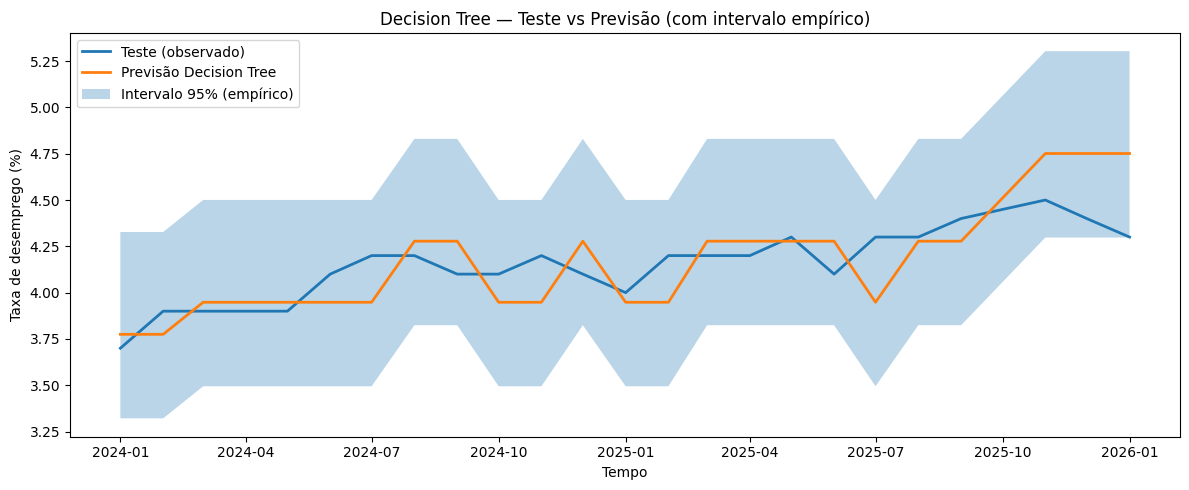

In [ ]:
# ===========================================================
# 5.5.7) GRÁFICO ADICIONAL — APENAS TESTE vs PREVISÃO + INTERVALO
# Objetivo: foco total no horizonte de avaliação (teste).
# ===========================================================

plt.figure(figsize=(12, 5))  # Define tamanho da figura (mesmo padrão do gráfico anterior).

plt.plot(                    # Série observada no teste (verdade).
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(                    # Previsão do modelo no teste.
    pred_dt.index,
    pred_dt.values,
    label="Previsão Decision Tree",
    linewidth=2
)

plt.fill_between(            # Faixa do intervalo empírico (aproximado).
    pred_dt.index,
    lower_dt.values,
    upper_dt.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("Decision Tree — Teste vs Previsão (com intervalo empírico)")  # Título.
plt.xlabel("Tempo")                                                    # Eixo x.
plt.ylabel("Taxa de desemprego (%)")                                   # Eixo y.
plt.legend()                                                           # Legenda.
plt.tight_layout()                                                     # Ajuste de layout.
plt.show()                                                             # Exibe.

### **MODELO 2 — RANDOM FOREST**

**DEFINIÇÃO DO MODELO**

In [ ]:
# ===========================================================
# 5.6) MODELO 2 — RANDOM FOREST
# Objetivo: ajustar o ensemble, prever no teste,
#           avaliar métricas e construir intervalo empírico.
# ===========================================================

# -------------------------
# 5.6.1) DEFINIÇÃO DO MODELO
# -------------------------
#
# Random Forest é um ensemble de várias árvores.
# Vantagens:
# - Reduz variância em relação a uma árvore única.
# - Geralmente melhora capacidade de generalização.

rf = RandomForestRegressor(   # Instancia o modelo.
    n_estimators=500,         # Número de árvores no ensemble.
    random_state=42           # Reprodutibilidade.
)

**TREINAMENTO**

In [ ]:
# -------------------------
# 5.6.2) TREINAMENTO
# -------------------------
# Treina apenas com dados passados (treino).

rf.fit(
    X_train_ml,
    y_train_ml
)

RandomForestRegressor(n_estimators=500, random_state=42)

**PREVISÃO NO TESTE (FUTURO)**

In [ ]:
# -------------------------
# 5.6.3) PREVISÃO NO TESTE
# -------------------------
# Previsão para o horizonte futuro (teste).

pred_rf = pd.Series(
    rf.predict(X_test_ml),
    index=y_test_ml.index
)

**AVALIAÇÃO (MÉTRICAS NO TESTE)**

In [ ]:
# -------------------------
# 5.6.4) AVALIAÇÃO NO TESTE
# -------------------------
# Métricas no teste medem generalização real.

metrics_rf = evaluate_forecast(
    y_true=y_test_ml,
    y_pred=pred_rf,
    model_name=f"RandomForest(lags={lags})"
)

ml_metrics_rows.append(metrics_rf)

print("Métricas — Random Forest (teste):")
show_model_metrics_table(metrics_rf)


Métricas — Random Forest (teste):


,Modelo,MAE,RMSE,MAPE(%),R2
0,RandomForest(lags=12),0.126,0.1527,3.0265,0.3332


**INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO**

In [ ]:
# -------------------------
# 5.6.5) INTERVALO DE PREVISÃO (EMPÍRICO)
# -------------------------
# Em ML não há intervalo paramétrico.
# Construímos intervalo aproximado via resíduos do treino.

pred_rf_train = pd.Series(
    rf.predict(X_train_ml),
    index=y_train_ml.index
)

resid_rf_train = (y_train_ml - pred_rf_train).dropna()

alpha = 0.05
q_low, q_high = resid_rf_train.quantile([alpha/2, 1 - alpha/2])

lower_rf = pred_rf + q_low
upper_rf = pred_rf + q_high


**GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO**

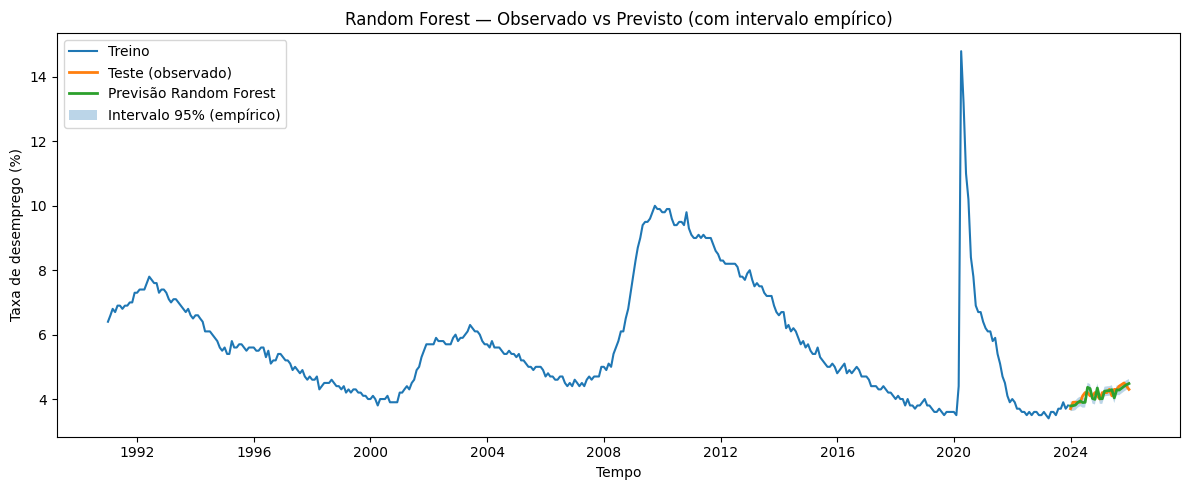

In [ ]:
# -------------------------
# 5.6.6) GRÁFICO COMPLETO — TREINO + TESTE + PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_train_ml.index,
    y_train_ml.values,
    label="Treino"
)

plt.plot(
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_rf.index,
    pred_rf.values,
    label="Previsão Random Forest",
    linewidth=2
)

plt.fill_between(
    pred_rf.index,
    lower_rf.values,
    upper_rf.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("Random Forest — Observado vs Previsto (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

**GRÁFICO ADICIONAL — TESTE + PREVISÃO + INTERVALO**

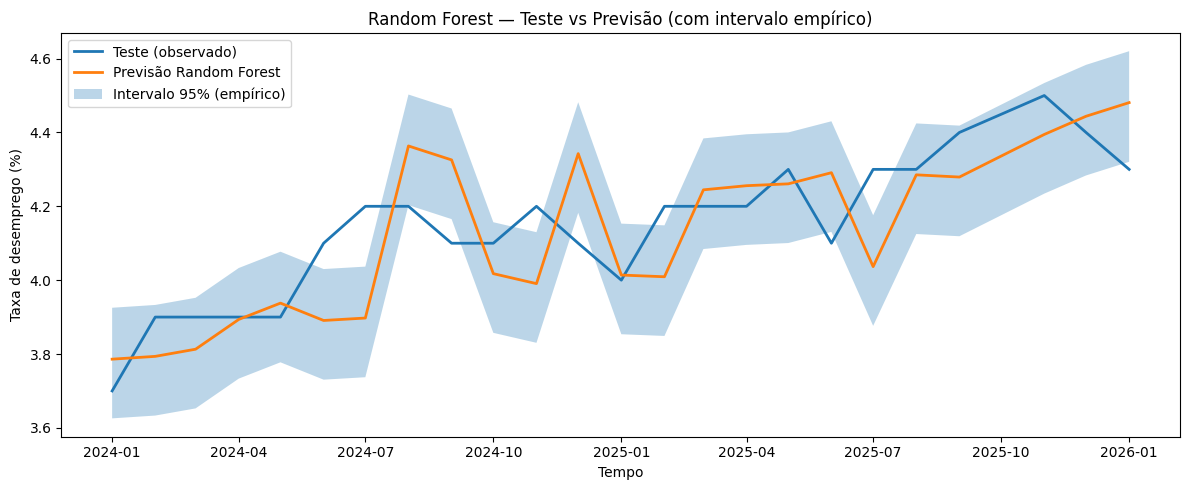

In [ ]:
# -------------------------
# 5.6.7) GRÁFICO ADICIONAL — APENAS TESTE vs PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_rf.index,
    pred_rf.values,
    label="Previsão Random Forest",
    linewidth=2
)

plt.fill_between(
    pred_rf.index,
    lower_rf.values,
    upper_rf.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("Random Forest — Teste vs Previsão (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

### **MODELO 3 — XGBOOST (Gradient Boosting)**

In [ ]:
# ===========================================================
# 5.7) MODELO 3 — XGBOOST (Gradient Boosting)
# ===========================================================

# Comentário operacional:
# - A instalação abaixo deve ser executada apenas se o xgboost não estiver disponível no ambiente.
# - Se já estiver instalado, você pode comentar a linha do pip.

!pip -q install xgboost  # Instala xgboost no Colab (pode ser removido se já existir).
from xgboost import XGBRegressor  # Importa o regressor do XGBoost.

#  XGBoost é boosting (árvores sequenciais) que busca reduzir erro iterativamente.
# Parâmetros-chave (visão didática):
# - n_estimators: nº de iterações/árvores.
# - learning_rate: passo de atualização (menor = mais conservador).
# - max_depth: complexidade de cada árvore base.
# - subsample / colsample_bytree: amostragem para reduzir overfitting.

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train_ml, y_train_ml)  # Ajusta no treino.
pred_xgb = pd.Series(            # Prevê no teste com índice temporal.
    xgb.predict(X_test_ml),
    index=y_test_ml.index
)


metrics_xgb = evaluate_forecast(  # Métricas padronizadas.
    y_test_ml,
    pred_xgb,
    model_name=f"XGBoost(lags={lags})"
)

ml_metrics_rows.append(metrics_xgb)  # Guarda para tabela final.

print("Métricas — XGBoost (tabela):")  # Cabeçalho.
show_model_metrics_table(metrics_xgb)  # Tabela por modelo.

Métricas — XGBoost (tabela):


,Modelo,MAE,RMSE,MAPE(%),R2
0,XGBoost(lags=12),0.2165,0.3239,5.2993,-1.998


 **Previsão**

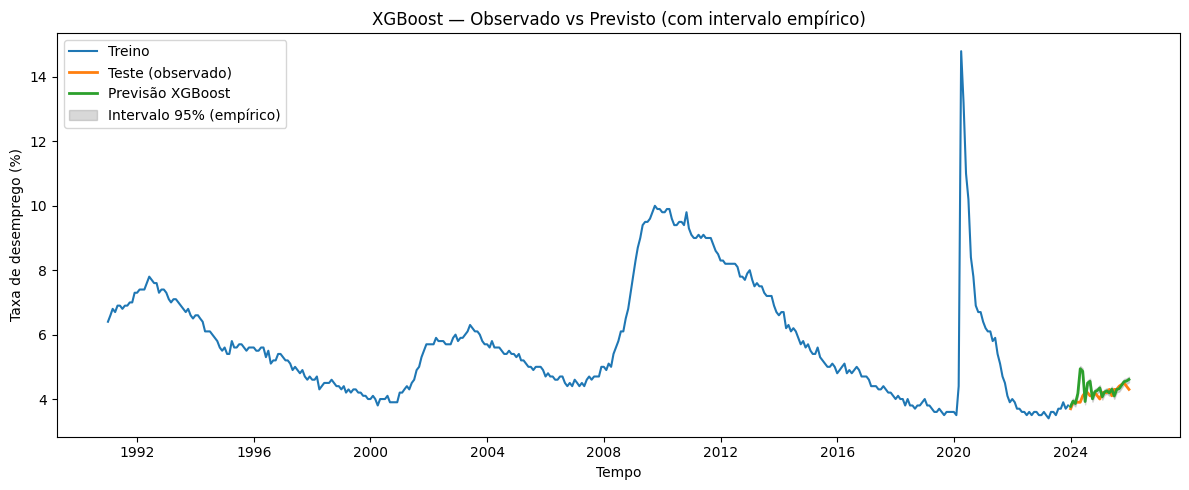

In [ ]:
# -------------------------
# (1) PREVISÃO NO TESTE
# -------------------------
pred_xgb = pd.Series(            # Prevê no teste com índice temporal.
    xgb.predict(X_test_ml),
    index=y_test_ml.index
)

# -------------------------
# (3) INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO
# -------------------------
pred_xgb_train = pd.Series(       # Previsão no treino (para construir resíduos)
    xgb.predict(X_train_ml),
    index=y_train_ml.index
)

resid_xgb_train = (y_train_ml - pred_xgb_train).dropna()  # Resíduos no treino.

alpha = 0.05  # 95% de intervalo (1 - alpha).
q_low, q_high = resid_xgb_train.quantile([alpha/2, 1 - alpha/2])  # Quantis empíricos.

lower_xgb = pred_xgb + q_low  # Limite inferior.
upper_xgb = pred_xgb + q_high # Limite superior.

# -------------------------
# (4) GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO
# -------------------------
plt.figure(figsize=(12, 5))  # Figura.
plt.plot(y_train_ml.index, y_train_ml.values, label="Treino")  # Série de treino.
plt.plot(y_test_ml.index, y_test_ml.values, label="Teste (observado)", linewidth=2)  # Observado.
plt.plot(pred_xgb.index, pred_xgb.values, label="Previsão XGBoost", linewidth=2)  # Previsto.

plt.fill_between(  # Faixa do intervalo de previsão (empírico).
    pred_xgb.index,
    lower_xgb.values,
    upper_xgb.values,
    color="gray",
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("XGBoost — Observado vs Previsto (com intervalo empírico)")  # Título.
plt.xlabel("Tempo")  # Eixo x.
plt.ylabel("Taxa de desemprego (%)")  # Eixo y.
plt.legend()  # Legenda.
plt.tight_layout()  # Layout.
plt.show()  # Exibe.


**GRÁFICO ADICIONAL — APENAS TESTE + PREVISÃO + INTERVALO**

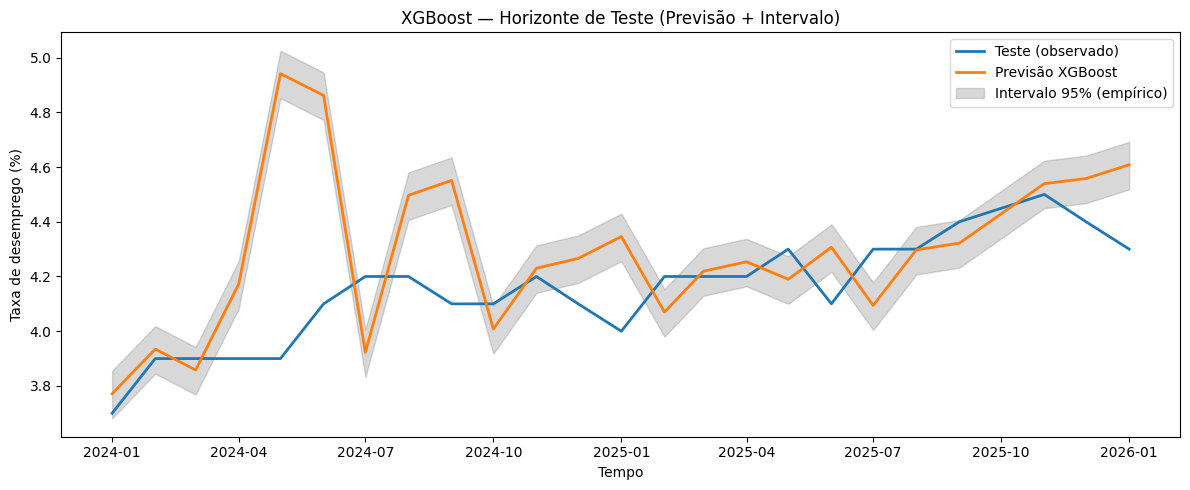

In [ ]:
# -------------------------
# (4B) GRÁFICO ADICIONAL — APENAS TESTE + PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))  # Nova figura focada apenas no teste.

plt.plot(
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_xgb.index,
    pred_xgb.values,
    label="Previsão XGBoost",
    linewidth=2
)

plt.fill_between(
    pred_xgb.index,
    lower_xgb.values,
    upper_xgb.values,
    color="gray",
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("XGBoost — Horizonte de Teste (Previsão + Intervalo)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

### **MODELO 4 — MLP (Rede Neural Feedforward) com Pipeline**

**DEFINIÇÃO DO MODELO**

In [ ]:
# ===========================================================
# 5.8) MODELO 4 — MLP (Rede Neural Feedforward) com Pipeline
# Objetivo: padronizar lags, treinar MLP, prever no teste,
#           avaliar métricas e construir intervalo empírico.
# ===========================================================

# -------------------------
# 5.8.1) DEFINIÇÃO DO PIPELINE (SCALER + MLP)
# -------------------------
#
# MLP é sensível à escala das variáveis explicativas (lags).
# Estratégia:
# - StandardScaler: padroniza as features (média 0, desvio 1).
# - MLPRegressor: ajusta a rede por otimização (Adam).

mlp = Pipeline(steps=[
    ("scaler", StandardScaler()),  # Padroniza as features (lags) para melhorar convergência.
    ("model", MLPRegressor(        # Rede MLP (regressão).
        hidden_layer_sizes=(64, 32),  # 2 camadas ocultas: 64 e 32 neurônios.
        activation="relu",            # ReLU como ativação.
        solver="adam",                # Otimizador Adam.
        random_state=42,              # Reprodutibilidade.
        max_iter=2000                 # Máximo de iterações (evita parar antes de convergir).
    ))
])

**TREINAMENTO**

In [ ]:
# -------------------------
# 5.8.2) TREINAMENTO
# -------------------------
#
# O pipeline garante que o scaler seja ajustado apenas no treino
# e aplicado no teste sem vazamento de informação.

mlp.fit(
    X_train_ml,
    y_train_ml
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000,
                              random_state=42))])

**PREVISÃO NO TESTE (FUTURO)**

In [ ]:
# -------------------------
# 5.8.3) PREVISÃO NO TESTE
# -------------------------
#
# Gera previsões para o horizonte futuro (teste),
# preservando o índice temporal.

pred_mlp = pd.Series(
    mlp.predict(X_test_ml),
    index=y_test_ml.index
)


**AVALIAÇÃO (MÉTRICAS NO TESTE)**

In [ ]:
# -------------------------
# 5.8.4) AVALIAÇÃO NO TESTE
# -------------------------
#
# Métricas no teste quantificam a qualidade preditiva do modelo
# em dados não vistos (cenário real).

metrics_mlp = evaluate_forecast(
    y_true=y_test_ml,
    y_pred=pred_mlp,
    model_name=f"MLP(lags={lags})"
)

ml_metrics_rows.append(metrics_mlp)

print("Métricas — MLP (teste):")
show_model_metrics_table(metrics_mlp)

Métricas — MLP (teste):


,Modelo,MAE,RMSE,MAPE(%),R2
0,MLP(lags=12),0.1766,0.2268,4.27,-0.4698


**INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO**

In [ ]:
# -------------------------
# 5.8.5) INTERVALO DE PREVISÃO (EMPÍRICO)
# -------------------------
#Em MLP não há intervalo paramétrico nativo.
# Então usamos um intervalo aproximado via quantis dos resíduos do treino:
# 1) prevê no treino
# 2) calcula resíduos (y - ŷ)
# 3) usa quantis (2,5% e 97,5%) para obter uma banda empírica de 95%

pred_mlp_train = pd.Series(
    mlp.predict(X_train_ml),
    index=y_train_ml.index
)

resid_mlp_train = (y_train_ml - pred_mlp_train).dropna()

alpha = 0.05
q_low, q_high = resid_mlp_train.quantile([alpha/2, 1 - alpha/2])

lower_mlp = pred_mlp + q_low
upper_mlp = pred_mlp + q_high


**GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO**

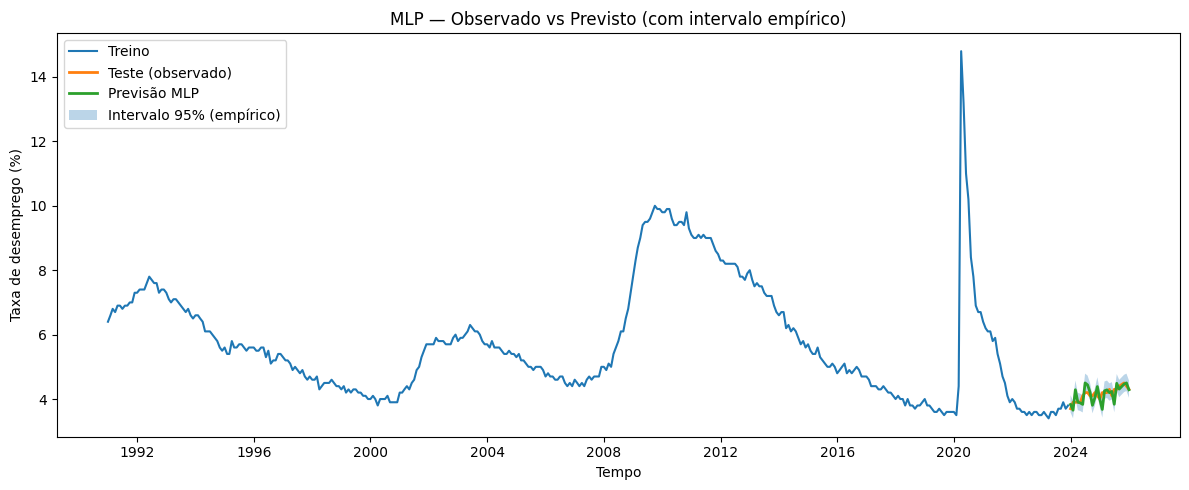

In [ ]:
# -------------------------
# 5.8.6) GRÁFICO COMPLETO — TREINO + TESTE + PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_train_ml.index,
    y_train_ml.values,
    label="Treino"
)

plt.plot(
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_mlp.index,
    pred_mlp.values,
    label="Previsão MLP",
    linewidth=2
)

plt.fill_between(
    pred_mlp.index,
    lower_mlp.values,
    upper_mlp.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("MLP — Observado vs Previsto (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

**GRÁFICO ADICIONAL — TESTE + PREVISÃO + INTERVALO**

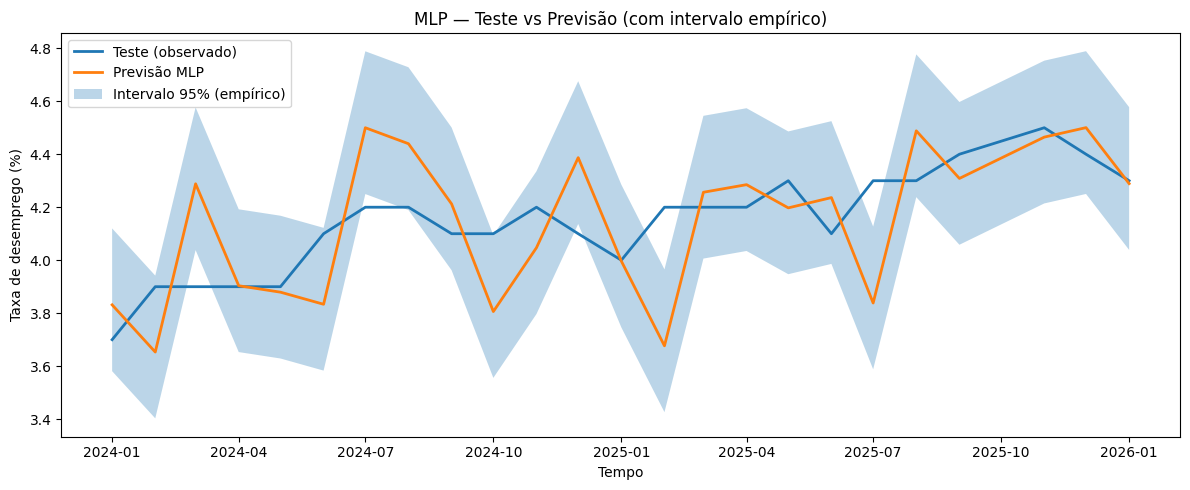

In [ ]:
# -------------------------
# 5.8.7) GRÁFICO ADICIONAL — APENAS TESTE vs PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_ml.index,
    y_test_ml.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_mlp.index,
    pred_mlp.values,
    label="Previsão MLP",
    linewidth=2
)

plt.fill_between(
    pred_mlp.index,
    lower_mlp.values,
    upper_mlp.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("MLP — Teste vs Previsão (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

### **MODELO 5 — LSTM (Deep Learning) com JANELAS (SEQUÊNCIAS)**

**DEFINIÇÃO DO MODELO**

In [ ]:
# ===========================================================
# 5.9) MODELO 5 — LSTM (Deep Learning) com JANELAS (SEQUÊNCIAS)
# Objetivo: transformar a série em sequências, treinar LSTM,
#           prever no teste, avaliar métricas e construir
#           intervalo empírico (quantis dos resíduos do treino).
# ===========================================================

# -------------------------
# 5.9.1) IMPORTS (KERAS/TENSORFLOW)
# -------------------------
# Comentário:
# TensorFlow fornece o backend e o Keras fornece a API para definir
# arquitetura, compilação e treinamento da rede.

import tensorflow as tf  # TensorFlow (backend).
from tensorflow.keras import layers, models  # Camadas e construtor de modelos.

# -------------------------
# 5.9.2) DEFINIÇÕES BÁSICAS (JANELA E CONSTRUÇÃO DE SEQUÊNCIAS)
# -------------------------
# Comentário:
# Diferença estrutural em relação aos modelos de ML com lags:
# - ML: X é 2D (amostras, lags).
# - LSTM: X é 3D (amostras, passos_de_tempo, features).
# Aqui a feature é 1 (a própria série).

window = 12  # Janela temporal: usa 12 meses anteriores para prever o próximo mês.

series_nn = y.copy()  # Série original (mantida para reconstruir índices depois).
X_seq, y_seq = make_sequences(series_nn, window=window)  # X_seq: (n, window, 1) / y_seq: (n,)


**SPLIT TEMPORAL (TREINO/TESTE) — SEM EMBARALHAR**

In [ ]:
# -------------------------
# 5.9.3) SPLIT TEMPORAL (TREINO/TESTE) — SEM EMBARALHAR
# -------------------------
# Comentário:
# O split precisa respeitar a ordem temporal.
# Estratégia:
# - Mantemos os últimos 'test_size' alvos (y_seq) como teste.
# - Todo o restante é treino.

split_seq = len(y_seq) - test_size  # Ponto de corte para deixar 'test_size' observações no teste.

X_train_seq = X_seq[:split_seq]  # Sequências de treino.
X_test_seq  = X_seq[split_seq:]  # Sequências de teste.
y_train_seq = y_seq[:split_seq]  # Alvos de treino.
y_test_seq  = y_seq[split_seq:]  # Alvos de teste.

**NORMALIZAÇÃO (APENAS COM ESTATÍSTICAS DO TREINO)**

In [ ]:
# -------------------------
# 5.9.4) NORMALIZAÇÃO (APENAS COM ESTATÍSTICAS DO TREINO)
# -------------------------
# Comentário:
# Redes neurais são sensíveis à escala.
# Regra de ouro:
# - Calcular média e desvio apenas no treino.
# - Aplicar a mesma transformação no teste (evita vazamento).

mean_tr = X_train_seq.mean()          # Média do treino.
std_tr  = X_train_seq.std() + 1e-8    # Desvio do treino (+epsilon para evitar divisão por zero).

X_train_seq_n = (X_train_seq - mean_tr) / std_tr  # Treino normalizado.
X_test_seq_n  = (X_test_seq  - mean_tr) / std_tr  # Teste normalizado com parâmetros do treino.

 **ARQUITETURA (LSTM MÍNIMA PARA REGRESSÃO)**

In [ ]:
#-------------------------
# 5.9.5) ARQUITETURA (LSTM MÍNIMA PARA REGRESSÃO)
# -------------------------
# Comentário:
# Estrutura didática:
# - Entrada: (window, 1)
# - LSTM(32): aprende dependências temporais
# - Dense(1): saída contínua para regressão

model_lstm = models.Sequential([
    layers.Input(shape=(window, 1)),  # Entrada: 12 passos e 1 feature.
    layers.LSTM(32),                  # Camada recorrente.
    layers.Dense(1)                   # Saída: 1 valor previsto.
])


**COMPILAÇÃO E TREINAMENTO**

In [ ]:

# -------------------------
# 5.9.6) COMPILAÇÃO E TREINAMENTO
# -------------------------
# Comentário:
# - loss="mse": erro quadrático médio (regressão).
# - validation_split=0.2: validação interna (apenas dentro do treino).

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

model_lstm.fit(
    X_train_seq_n, y_train_seq,  # Treino.
    validation_split=0.2,         # 20% do treino vira validação interna.
    epochs=60,                    # Épocas (configuração didática).
    batch_size=16,                # Lote.
    verbose=0                     # Sem logs (Colab mais limpo).
)

**PREVISÃO NO TESTE (FUTURO)**

In [ ]:
# -------------------------
# 5.9.7) PREVISÃO NO TESTE
# -------------------------
# Comentário:
# O predict retorna array (n, 1). Em seguida achatamos para (n,).

pred_lstm = model_lstm.predict(X_test_seq_n, verbose=0).flatten()

**RECONSTRUÇÃO DO ÍNDICE TEMPORAL (ALINHAMENTO)**

In [ ]:
# -------------------------
# 5.9.8) RECONSTRUÇÃO DO ÍNDICE TEMPORAL (ALINHAMENTO)
# -------------------------
# Comentário:
# Ao formar janelas de tamanho 'window', perdemos os primeiros 'window' timestamps.
# O primeiro alvo y_seq corresponde ao tempo series_nn.index[window].
# Portanto o índice do teste começa em: window + split_seq.

idx_test = series_nn.index[window + split_seq : window + split_seq + len(y_test_seq)]

pred_lstm_s = pd.Series(pred_lstm, index=idx_test)   # Previsão com índice temporal.
y_test_s    = pd.Series(y_test_seq, index=idx_test)  # Observado com o mesmo índice.

**AVALIAÇÃO (MÉTRICAS NO TESTE)**

In [ ]:
# -------------------------
# 5.9.9) AVALIAÇÃO NO TESTE (MÉTRICAS)
# -------------------------
# Comentário:
# Métricas calculadas apenas no horizonte de teste.

metrics_lstm = evaluate_forecast(
    y_true=y_test_s,
    y_pred=pred_lstm_s,
    model_name=f"LSTM(window={window})"
)

ml_metrics_rows.append(metrics_lstm)

print("Métricas — LSTM (teste):")
show_model_metrics_table(metrics_lstm)


Métricas — LSTM (teste):


,Modelo,MAE,RMSE,MAPE(%),R2
0,LSTM(window=12),0.0928,0.1095,2.2246,0.6572


**INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO**

In [ ]:
# ===========================================================
# 5.9.10) INTERVALO DE PREVISÃO (EMPÍRICO) VIA RESÍDUOS DO TREINO
# ===========================================================
# Comentário:
# LSTM não retorna intervalo paramétrico.
# Abordagem didática:
# 1) prever no treino (mesmas janelas do treino)
# 2) calcular resíduos do treino
# 3) usar quantis (2,5% e 97,5%) como banda empírica de 95%
#
# Observação:
# Esse intervalo é uma aproximação: assume que a distribuição do erro
# no futuro é similar à do erro observado no treino.

# (1) Previsão no treino (para obter resíduos empíricos)
pred_lstm_train = model_lstm.predict(X_train_seq_n, verbose=0).flatten()

# (2) Índice temporal do treino (após criação das janelas)
idx_train = series_nn.index[window : window + len(y_train_seq)]

y_train_s = pd.Series(y_train_seq, index=idx_train)
pred_lstm_train_s = pd.Series(pred_lstm_train, index=idx_train)

# (3) Resíduos no treino
resid_lstm_train = (y_train_s - pred_lstm_train_s).dropna()

# (4) Quantis empíricos para 95%
alpha = 0.05
q_low, q_high = resid_lstm_train.quantile([alpha/2, 1 - alpha/2])

lower_lstm = pred_lstm_s + q_low
upper_lstm = pred_lstm_s + q_high


**GRÁFICO — OBSERVADO VS PREVISTO + INTERVALO**

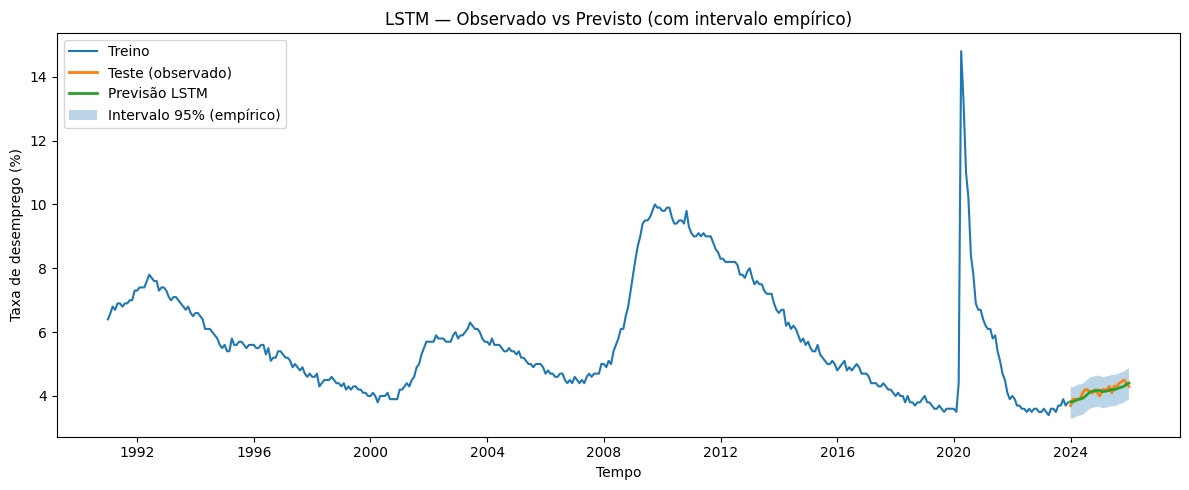

In [ ]:
# -------------------------
# 5.9.11) GRÁFICO COMPLETO — TREINO + TESTE + PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_train_s.index,
    y_train_s.values,
    label="Treino"
)

plt.plot(
    y_test_s.index,
    y_test_s.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_lstm_s.index,
    pred_lstm_s.values,
    label="Previsão LSTM",
    linewidth=2
)

plt.fill_between(
    pred_lstm_s.index,
    lower_lstm.values,
    upper_lstm.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("LSTM — Observado vs Previsto (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()


**GRÁFICO ADICIONAL — TESTE + PREVISÃO + INTERVALO**

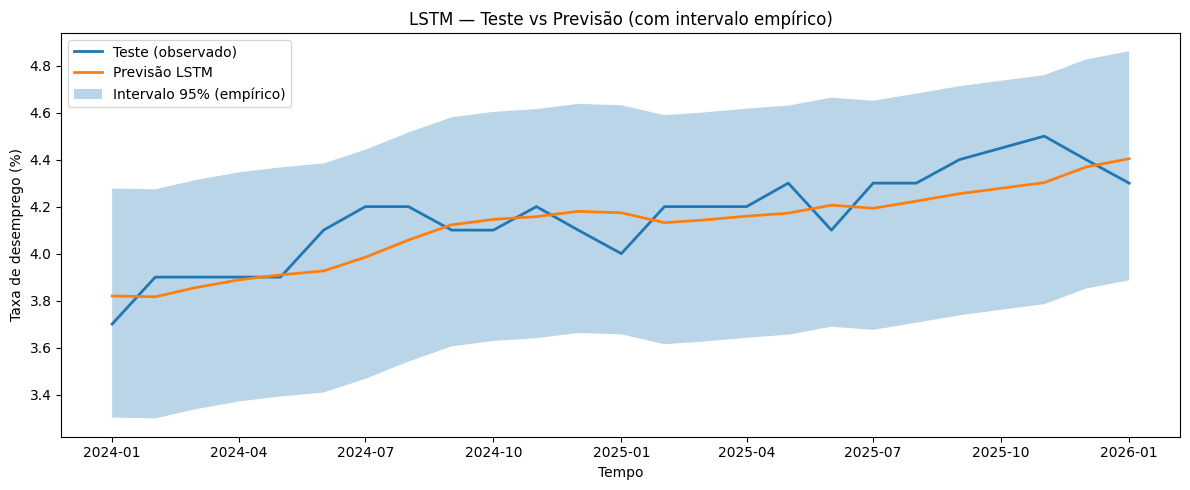

In [ ]:
# -------------------------
# 5.9.12) GRÁFICO ADICIONAL — APENAS TESTE + PREVISÃO + INTERVALO
# -------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_s.index,
    y_test_s.values,
    label="Teste (observado)",
    linewidth=2
)

plt.plot(
    pred_lstm_s.index,
    pred_lstm_s.values,
    label="Previsão LSTM",
    linewidth=2
)

plt.fill_between(
    pred_lstm_s.index,
    lower_lstm.values,
    upper_lstm.values,
    alpha=0.3,
    label="Intervalo 95% (empírico)"
)

plt.title("LSTM — Teste vs Previsão (com intervalo empírico)")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

### **6) COMPARAÇÃO CONSOLIDADA DOS MODELOS**

**TABELA**

Tabela consolidada (ordenada por RMSE):
                         Modelo       MAE      RMSE    MAPE(%)        R2
5               LSTM(window=12)  0.092768  0.109501   2.224582  0.657248
3         RandomForest(lags=12)  0.125958  0.152725   3.026472  0.333243
2         DecisionTree(lags=12)  0.158078  0.194688   3.759704 -0.083488
4                  MLP(lags=12)  0.176567  0.226750   4.270009 -0.469750
1  SARIMA(1, 1, 1)(0, 0, 1, 12)  0.327370  0.367551   7.747836 -2.813480
0                ARIMA(2, 1, 2)  0.511768  0.558749  12.236326 -7.812930


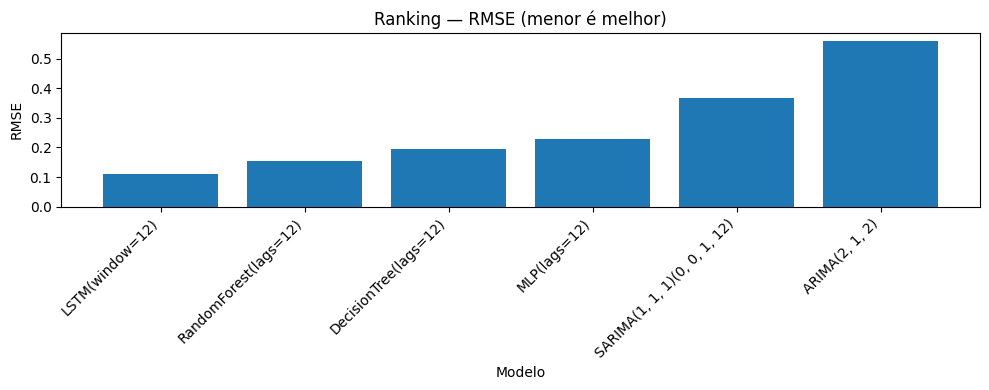

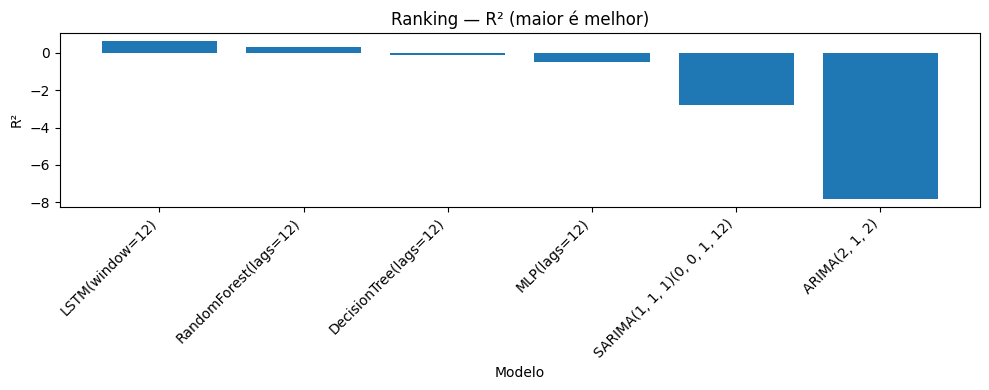

In [ ]:
# -----------------------------------------------------------
# 6) COMPARAÇÃO CONSOLIDADA (TABELA + RANKING: ERROS E R²)
#
# Objetivo do bloco:
# - Consolidar (em uma única tabela) as métricas geradas em cada modelo
# - Gerar rankings por critério de erro (ex.: RMSE) e por qualidade de ajuste (R²)
# - Produzir gráficos simples para discussão em sala (comparação direta)
#
# Premissas operacionais:
# - Cada variável "metrics_*" deve ser um dicionário retornado por evaluate_forecast()
# - As chaves esperadas são: ["Modelo", "MAE", "RMSE", "MAPE(%)", "R2"]
# - Se algum modelo não foi executado (ex.: XGBoost), não inclua no consolidado
# -----------------------------------------------------------

all_metrics = []  # Cria lista vazia que irá armazenar os dicionários de métricas (um por modelo).

all_metrics.append(metrics_arima)  # Inclui métricas do ARIMA (avaliado no conjunto de teste).
all_metrics.append(metrics_sarima)  # Inclui métricas do SARIMA (avaliado no conjunto de teste).

all_metrics.append(metrics_dt)  # Inclui métricas da Árvore de Decisão (supervisionado com lags).
all_metrics.append(metrics_rf)  # Inclui métricas do Random Forest (supervisionado com lags).

# all_metrics.append(metrics_xgb)  # Inclui métricas do XGBoost, apenas se o bloco do XGBoost foi executado.

all_metrics.append(metrics_mlp)  # Inclui métricas do MLP (pipeline com scaler + rede).
all_metrics.append(metrics_lstm)  # Inclui métricas do LSTM (sequências/janelas no tempo).

df_all = pd.DataFrame(all_metrics)  # Constrói DataFrame consolidado (cada linha = um modelo; cada coluna = uma métrica).
df_all = df_all.sort_values("RMSE")  # Ordena por RMSE (menor RMSE indica menor erro típico em escala original).

print("Tabela consolidada (ordenada por RMSE):")  # Cabeçalho para leitura no output do notebook.
print(df_all)  # Exibe tabela completa de métricas para comparação.

plt.figure(figsize=(10, 4))  # Cria figura do ranking por RMSE.
plt.bar(df_all["Modelo"], df_all["RMSE"])  # Barra por modelo usando RMSE como altura.
plt.title("Ranking — RMSE (menor é melhor)")  # Título do gráfico (critério de erro).
plt.xlabel("Modelo")  # Nome do eixo x (modelos).
plt.ylabel("RMSE")  # Nome do eixo y (erro em escala da série).
plt.xticks(rotation=45, ha="right")  # Rotaciona rótulos para evitar sobreposição e melhora leitura.
plt.tight_layout()  # Ajusta margens para não cortar rótulos.
plt.show()  # Exibe gráfico.

plt.figure(figsize=(10, 4))  # Cria figura do ranking por R².
plt.bar(df_all["Modelo"], df_all["R2"])  # Barra por modelo usando R² como altura.
plt.title("Ranking — R² (maior é melhor)")  # Título do gráfico (critério de explicação de variância no teste).
plt.xlabel("Modelo")  # Nome do eixo x (modelos).
plt.ylabel("R²")  # Nome do eixo y (coeficiente de determinação).
plt.xticks(rotation=45, ha="right")  # Rotaciona rótulos para leitura.
plt.tight_layout()  # Ajusta margens.
plt.show()  # Exibe gráfico.

**GRÁFICO CONSOLIDADO — SÉRIE ORIGINAL + PREVISÕES (TESTE)**

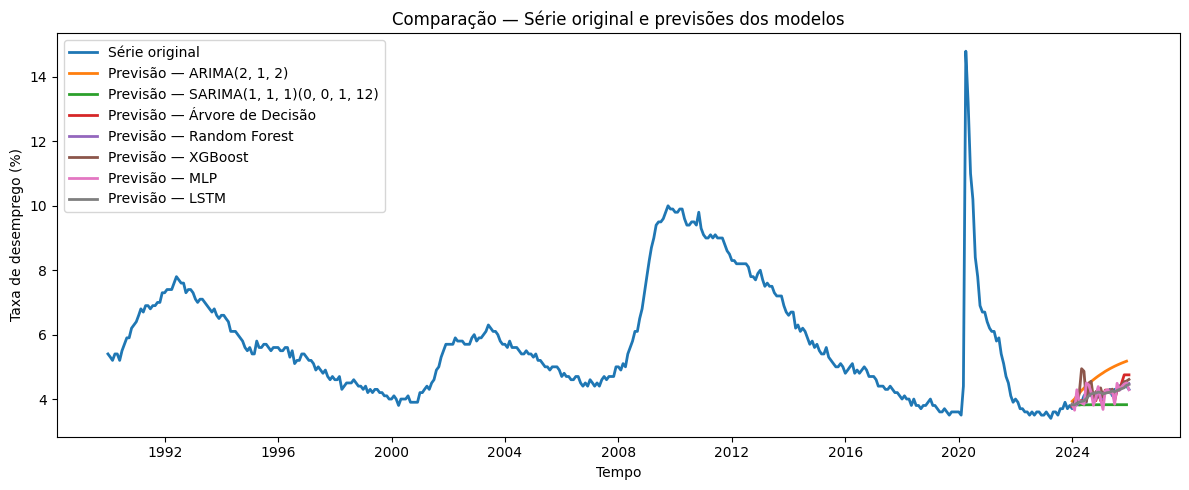

In [ ]:
# -----------------------------------------------------------
# (EXTRA) GRÁFICO CONSOLIDADO — SÉRIE ORIGINAL + PREVISÕES (TESTE)
# -----------------------------------------------------------

# Monta dicionário com todas as previsões disponíveis
preds_all = {}

# ARIMA
try:
    preds_all[f"ARIMA{best_order}"] = pred_arima
except NameError:
    pass

# SARIMA
try:
    preds_all[f"SARIMA{best_order_s}{best_seasonal_s}"] = pred_sarima
except NameError:
    pass

# Árvore de Decisão
try:
    preds_all["Árvore de Decisão"] = pred_dt
except NameError:
    pass

# Random Forest
try:
    preds_all["Random Forest"] = pred_rf
except NameError:
    pass

# XGBoost
try:
    preds_all["XGBoost"] = pred_xgb
except NameError:
    pass

# MLP
try:
    preds_all["MLP"] = pred_mlp
except NameError:
    pass

# LSTM
try:
    preds_all["LSTM"] = pred_lstm_s
except NameError:
    pass


# -------------------------
# GRÁFICO
# -------------------------

plt.figure(figsize=(12, 5))

# Série original completa
plt.plot(
    y.index,
    y.values,
    label="Série original",
    linewidth=2
)

# Plota previsões (somente onde existem — normalmente no teste)
for name, pred_s in preds_all.items():
    pred_s = pd.Series(pred_s).sort_index()
    plt.plot(
        pred_s.index,
        pred_s.values,
        linewidth=2,
        label=f"Previsão — {name}"
    )

plt.title("Comparação — Série original e previsões dos modelos")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()

**GRÁFICO PADRONIZADO — PREVISÕES DOS MODELOS**

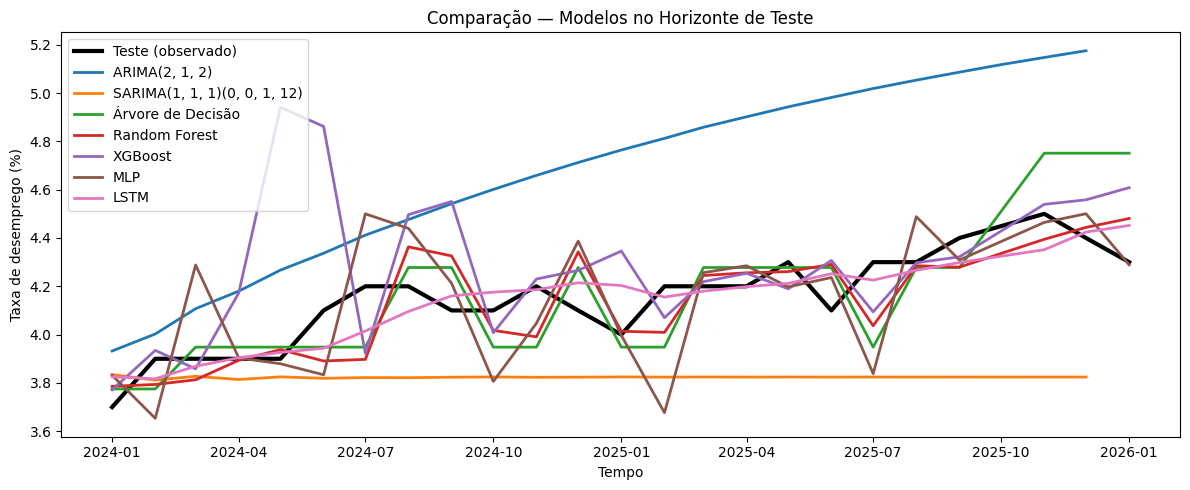

In [ ]:
# -----------------------------------------------------------
# (EXTRA) DICIONÁRIO PADRONIZADO — PREVISÕES DOS MODELOS
# -----------------------------------------------------------
preds_all = {}

# ARIMA / SARIMA
try:
    preds_all[f"ARIMA{best_order}"] = pred_arima
except NameError:
    pass

try:
    preds_all[f"SARIMA{best_order_s}{best_seasonal_s}"] = pred_sarima
except NameError:
    pass

# Árvore de Decisão
try:
    preds_all["Árvore de Decisão"] = pred_dt
except NameError:
    pass

# Random Forest
try:
    preds_all["Random Forest"] = pred_rf
except NameError:
    pass

# XGBoost
try:
    preds_all["XGBoost"] = pred_xgb
except NameError:
    pass

# MLP
try:
    preds_all["MLP"] = pred_mlp
except NameError:
    pass

# LSTM
try:
    preds_all["LSTM"] = pred_lstm_s
except NameError:
    pass


# -----------------------------------------------------------
# (EXTRA 2) GRÁFICO — TESTE (PRETO) + PREVISÕES DOS MODELOS
# -----------------------------------------------------------

# Define qual série de teste usar (ML usa y_test_ml; LSTM usa y_test_s)
if "y_test_ml" in globals():
    test_series = y_test_ml
else:
    test_series = y_test_s

plt.figure(figsize=(12, 5))

# Teste (observado) em preto e mais grosso
plt.plot(
    test_series.index,
    test_series.values,
    color="black",
    linewidth=3,
    label="Teste (observado)"
)

# Previsões dos modelos
for name, pred_s in preds_all.items():
    pred_s = pd.Series(pred_s).sort_index()
    plt.plot(
        pred_s.index,
        pred_s.values,
        linewidth=2,
        label=name
    )

plt.title("Comparação — Modelos no Horizonte de Teste")
plt.xlabel("Tempo")
plt.ylabel("Taxa de desemprego (%)")
plt.legend()
plt.tight_layout()
plt.show()